# Running FAIR-Checker over 2 years, lessons learned

This notebook presents a comprehensive report on two years of running the FAIR-checker tool, which performs FAIR (Findable, Accessible, Interoperable, Reusable) assessments on digital resources. The analysis includes an overview of assessment results, trends over time, and insights into the FAIRness of evaluated resources.

In [1]:
from SPARQLWrapper import SPARQLWrapper, JSON
from pandas import DataFrame
import json
import os

import pandas as pd
from datetime import datetime, timedelta   
from tqdm.notebook import tqdm

import seaborn as sns
import matplotlib.pyplot as plt 


# a function to execute a SPARQL query and return results as a panda DataFrame  
def execute_sparql_query(query):
    sparql.setQuery(query)
    sparql.setReturnFormat(JSON)
    results = sparql.query().convert()
    # print(json.dumps(results, indent=2))
    # Convert results to a DataFrame
    df = DataFrame(results['results']['bindings'])
    # Convert each column to a more readable format
    for column in df.columns:
        df[column] = df[column].apply(lambda x: x['value'] if isinstance(x, dict) and 'value' in x else x)
    return df

# Define the SPARQL endpoint URL
endpoint_url = "http://localhost:3030/fairchecker/query"

# Create a SPARQLWrapper instance
sparql = SPARQLWrapper(endpoint_url)
# Set the return format to JSON
sparql.setReturnFormat(JSON)    

In [ ]:
# Total number of FAIR assessments
query = """
PREFIX schema: <http://schema.org/>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX dqv: <http://www.w3.org/ns/dqv#>
PREFIX : <https://fair-checker.france-bioinformatique.fr/data#> 

SELECT (count(?s) as ?nbEval) WHERE {
  ?s rdf:type dqv:QualityMeasurement ;
      dqv:isMeasurementOf ?principle .
  FILTER(?principle NOT IN (:None))
} 

"""
results = execute_sparql_query(query)
results

,nbEval
0,2511512


In [342]:
query = """
PREFIX schema: <http://schema.org/>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX xsd: <http://www.w3.org/2001/XMLSchema#>
PREFIX dqv: <http://www.w3.org/ns/dqv#>
PREFIX prov: <http://www.w3.org/ns/prov#>
PREFIX : <https://fair-checker.france-bioinformatique.fr/data#> 

SELECT ?computedOn (COUNT(?s) AS ?nbEval) WHERE {
    ?s rdf:type dqv:QualityMeasurement ;
        prov:generatedAtTime ?time ;
        dqv:value ?value ;
        dqv:isMeasurementOf ?principle ;
        dqv:computedOn ?computedOn .
    FILTER (?principle NOT IN (:None))
} 
GROUP BY ?computedOn
HAVING (COUNT(?s) >= 124)
ORDER BY DESC(?nbEval)
"""
results = execute_sparql_query(query)
results

,computedOn,nbEval
0,http://orkg.org/orkg/class/Resource,35856
1,https://www.pxweb.bfs.admin.ch/Default.aspx?,8688
2,https://github.com/BFO-ontology/BFO/blob/maste...,6298
3,https://raw.githubusercontent.com/frmichel/tax...,5630
4,https://data.inrae.fr/dataset.xhtml?persistent...,4985
...,...,...
432,https://doi.org/10.1145/3373017.3373049,124
433,https://doi.org/10.14569/ijacsa.2020.0110761,124
434,https://doi.org/10.15454/SCTMIU,124
435,https://doi.org/10.3390/e21111083,124


## ✅ Basic stats on the KG classes and properties 

In [226]:
query = """
PREFIX schema: <http://schema.org/>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX xsd: <http://www.w3.org/2001/XMLSchema#>
PREFIX dqv: <http://www.w3.org/ns/dqv#>
PREFIX prov: <http://www.w3.org/ns/prov#>
PREFIX : <https://fair-checker.france-bioinformatique.fr/data#> 

SELECT ?class (COUNT(?s) AS ?count ) { ?s a ?class } GROUP BY ?class ORDER BY desc(?count)
"""
results = execute_sparql_query(query)
results

,class,count
0,http://www.w3.org/ns/dqv#QualityMeasurement,2548289
1,http://www.w3.org/ns/dqv#Dimension,12


In [222]:
query = """
PREFIX schema: <http://schema.org/>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX xsd: <http://www.w3.org/2001/XMLSchema#>
PREFIX dqv: <http://www.w3.org/ns/dqv#>
PREFIX prov: <http://www.w3.org/ns/prov#>
PREFIX : <https://fair-checker.france-bioinformatique.fr/data#> 

SELECT ?p (COUNT(?s) AS ?count ) { ?s ?p ?o } GROUP BY ?p ORDER BY desc(?count)
"""
results = execute_sparql_query(query)
results

,p,count
0,http://www.w3.org/1999/02/22-rdf-syntax-ns#type,2548301
1,http://www.w3.org/2000/01/rdf-schema#seeAlso,2548289
2,http://www.w3.org/ns/dqv#computedOn,2548289
3,http://www.w3.org/ns/dqv#isMeasurementOf,2548289
4,http://www.w3.org/ns/dqv#value,2548289
5,http://www.w3.org/ns/prov#generatedAtTime,2548289
6,http://www.w3.org/ns/prov#wasAttributedTo,2548289
7,http://www.w3.org/2004/02/skos/core#definition,12
8,http://www.w3.org/2004/02/skos/core#prefLabel,12
9,http://www.w3.org/ns/dqv#inCategory,12


## ✅ Cumulative number of FAIR assessments over time

In [229]:
query = """
PREFIX schema: <http://schema.org/>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX xsd: <http://www.w3.org/2001/XMLSchema#>
PREFIX dqv: <http://www.w3.org/ns/dqv#>
PREFIX prov: <http://www.w3.org/ns/prov#>
PREFIX : <https://fair-checker.france-bioinformatique.fr/data#> 

SELECT ?year ?month (count(?s) as ?nbEval) WHERE {
  ?s rdf:type dqv:QualityMeasurement ;
      prov:generatedAtTime ?time ;
      dqv:isMeasurementOf ?principle .
  FILTER(?principle NOT IN (:None))
} 
GROUP BY (YEAR(?time) AS ?year) (MONTH(?time) AS ?month)
ORDER BY ?year ?month
"""
results = execute_sparql_query(query)
results

,year,month,nbEval
0,2020,12,376
1,2021,01,327
2,2021,02,842
3,2021,03,1220
4,2021,04,4399
5,2021,05,4241
6,2021,06,3091
7,2021,07,1643
8,2021,08,484
9,2021,09,1916


,year,month,nbEval,date,cumSum
0,2020,12,376,2020-12-01,376
1,2021,01,327,2021-01-01,703
2,2021,02,842,2021-02-01,1545
3,2021,03,1220,2021-03-01,2765
4,2021,04,4399,2021-04-01,7164
5,2021,05,4241,2021-05-01,11405
6,2021,06,3091,2021-06-01,14496
7,2021,07,1643,2021-07-01,16139
8,2021,08,484,2021-08-01,16623
9,2021,09,1916,2021-09-01,18539


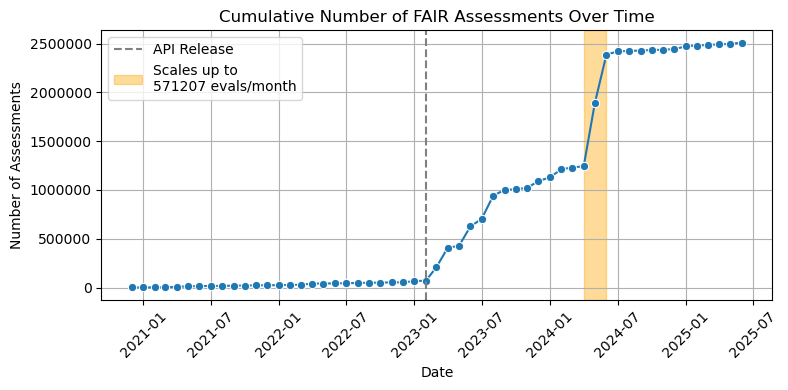

In [246]:
# concatenate year and month into a single datetime column
results['date'] = results.apply(lambda row: datetime(int(row['year']), int(row['month']), 1), axis=1)
# compute the cumulative sum of the number of assessments
results["nbEval"] = results["nbEval"].astype(int)
results = results.sort_values(by='date')    
# compute the cumulative sum of the number of assessments
results['cumSum'] = results['nbEval'].cumsum()
display(results)


# plot a seaborn cumulative sum of the number of FAIR assessments over time
plt.figure(figsize=(8, 4))
sns.lineplot(data=results, x='date', y='cumSum', marker='o')
# insert a star marker for the 26th point
plt.axvline(x=results['date'].iloc[26], color='gray', linestyle='--', label='API Release')
# insert a filled rectangle including the 40th and 42th points
mean_peak = (results["nbEval"].iloc[41] + results["nbEval"].iloc[42]) / 2
mean_peak = int(mean_peak)
plt.axvspan(results['date'].iloc[40], results['date'].iloc[42], color='orange', alpha=0.4, label=f'Scales up to\n{mean_peak} evals/month')
# insert a vertical line for the
plt.legend()    
plt.grid(True)
plt.title('Cumulative Number of FAIR Assessments Over Time')
plt.xlabel('Date')
plt.xticks(rotation=45)
# dont use scientific notation for y-axis
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.ylabel('Number of Assessments')
plt.savefig('cumulative_fair_assessments_over_time.pdf', bbox_inches='tight', format='pdf')
plt.show()

## ✅ Most evaluated domains

In [3]:
Ymin = 2021
Ymax = 2025

query = f"""
PREFIX schema: <http://schema.org/>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX xsd: <http://www.w3.org/2001/XMLSchema#>
PREFIX dqv: <http://www.w3.org/ns/dqv#>
PREFIX prov: <http://www.w3.org/ns/prov#>
PREFIX : <https://fair-checker.france-bioinformatique.fr/data#> 

SELECT ?computedOn (count(?s) AS ?nb) WHERE {{
    ?s rdf:type dqv:QualityMeasurement ;
        prov:generatedAtTime ?time ;
        dqv:isMeasurementOf ?principle ;
        dqv:computedOn ?computedOn .
    FILTER (?principle NOT IN (:None))
    FILTER (?time >= "{Ymin}-01-01T00:00:00Z"^^xsd:dateTime && ?time <= "{Ymax}-12-31T23:59:59Z"^^xsd:dateTime)
}} 
GROUP BY ?computedOn
ORDER BY desc(?nb)
"""

results = execute_sparql_query(query)
results

,computedOn,nb
0,http://orkg.org/orkg/class/Resource,35856
1,https://www.pxweb.bfs.admin.ch/Default.aspx?,8688
2,https://github.com/BFO-ontology/BFO/blob/maste...,6298
3,https://raw.githubusercontent.com/frmichel/tax...,5630
4,https://data.inrae.fr/dataset.xhtml?persistent...,4985
...,...,...
102168,https://www.fr.ch/sej/vie-quotidienne/structur...,1
102169,https://www.geysse.com/,1
102170,https://www.scidb.cn/en/detail?dataSetId=72062...,1
102171,https://zenodo.org/record/7655308#.ZBEd9JHMKUk,1


In [4]:
from urllib.parse import urlparse

# for each row in the result dataframe, extract the domain of each URL
def extract_domain(url):
    if pd.isna(url):
        return None
    domain = urlparse(url).netloc
    return domain

results['domain'] = results['computedOn'].apply(extract_domain)
results

,computedOn,nb,domain
0,http://orkg.org/orkg/class/Resource,35856,orkg.org
1,https://www.pxweb.bfs.admin.ch/Default.aspx?,8688,www.pxweb.bfs.admin.ch
2,https://github.com/BFO-ontology/BFO/blob/maste...,6298,github.com
3,https://raw.githubusercontent.com/frmichel/tax...,5630,raw.githubusercontent.com
4,https://data.inrae.fr/dataset.xhtml?persistent...,4985,data.inrae.fr
...,...,...,...
102168,https://www.fr.ch/sej/vie-quotidienne/structur...,1,www.fr.ch
102169,https://www.geysse.com/,1,www.geysse.com
102170,https://www.scidb.cn/en/detail?dataSetId=72062...,1,www.scidb.cn
102171,https://zenodo.org/record/7655308#.ZBEd9JHMKUk,1,zenodo.org


In [5]:
results['nb'] = results['nb'].astype(int)  # Convert 'nb' column

domain_counts = results.groupby("domain")["nb"].sum().reset_index()
# sort the domain counts in descending order
domain_counts = domain_counts.sort_values(by="nb", ascending=False)
domain_counts.to_csv(f"domain_counts_{Ymin}_{Ymax}.csv", index=False)
domain_counts

,domain,nb
1801,www.data.gv.at,742830
1191,orkg.org,522600
526,doi.org,452271
1628,ws.cso.ie,194589
96,arxiv.org,74195
...,...,...
1613,webfs.oecd.org,1
1893,www.geodata.cn,1
691,gctype.wdcm.org,1
1673,www.archiviodistato.prato.it,1


/var/folders/x1/d1nyvpvs0td0htxzsv9x6ggw0000gn/T/ipykernel_81930/4236396938.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="nb", y="domain", data=domain_counts, palette="viridis")


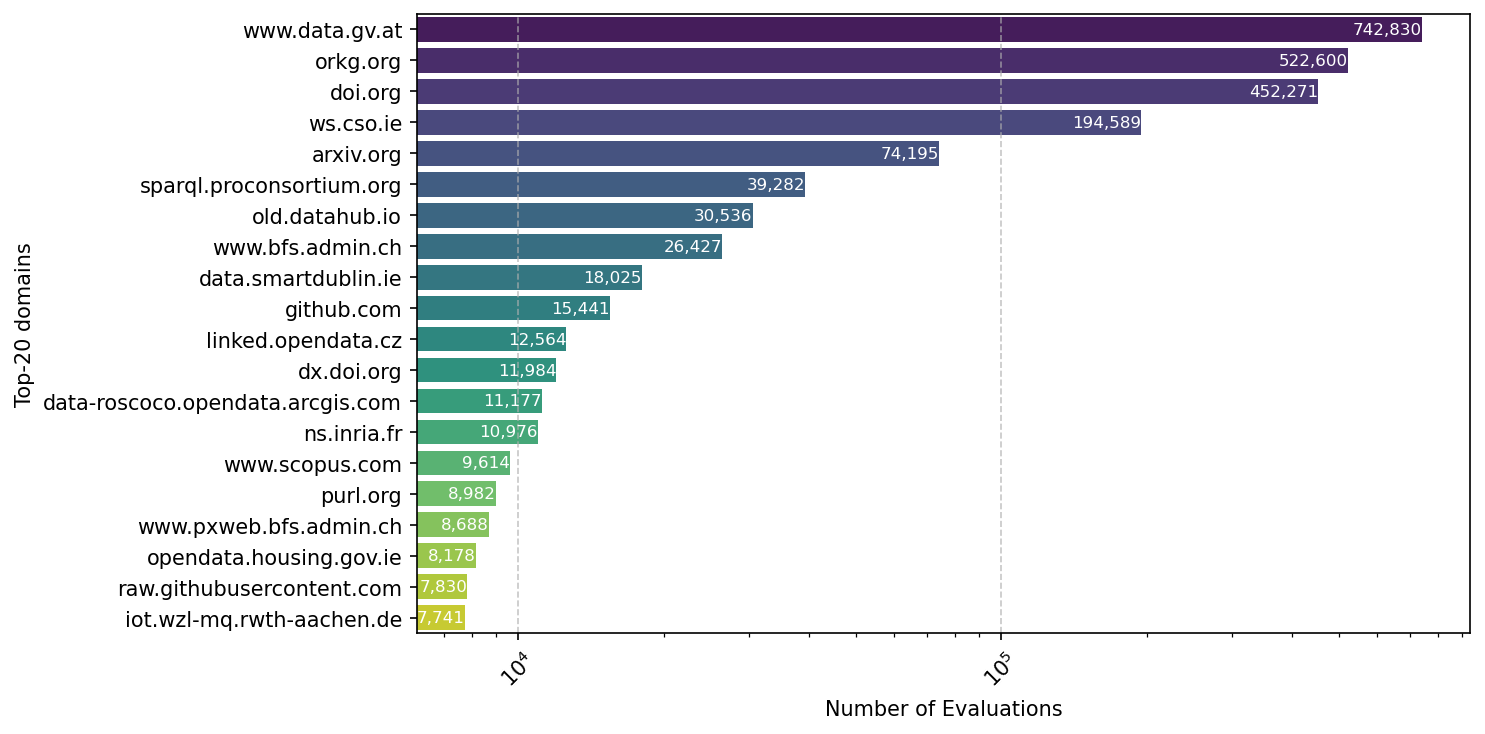

In [15]:
K = 20
domain_counts = domain_counts[:K]  # Filter out domains with zero evaluations
# plot the number of evaluations per domain by using seaborn,
# use an horizontal bar plot, sort by number of evaluations, use a log scale for the x-axis
plt.figure(figsize=(10, 5), dpi=150)

# domain_counts = domain_counts.sort_values(by='nb', ascending=False)
sns.barplot(x="nb", y="domain", data=domain_counts, palette="viridis")
plt.xscale('log')
# plt.xticks(rotation=45)
# plt.xyticks(rotation=45)
# display the value in the bar in white on the right side of the bar
for index, value in enumerate(domain_counts['nb']):
    plt.text(value, index, f'{value:,}', color='white', va='center', fontsize=8, ha='right')

plt.xticks(rotation=45)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
#plt.title('Number of Evaluations per Domain')
plt.xlabel('Number of Evaluations')
plt.ylabel(f'Top-{K} domains')
plt.savefig(f"number_of_evaluations_per_domain_{Ymin}_{Ymax}.pdf", dpi=300, bbox_inches='tight', format='pdf')
plt.show()

## ✅ Overall progress in FAIRification

In [136]:
output = pd.DataFrame()

for YEAR in tqdm(range(2021,2026)):
    query = f"""
    PREFIX schema: <http://schema.org/>
    PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
    PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
    PREFIX xsd: <http://www.w3.org/2001/XMLSchema#>
    PREFIX dqv: <http://www.w3.org/ns/dqv#>
    PREFIX prov: <http://www.w3.org/ns/prov#>
    PREFIX : <https://fair-checker.france-bioinformatique.fr/data#> 

    SELECT ?value (count(?s) AS ?nb) WHERE {{
        ?s rdf:type dqv:QualityMeasurement ;
            prov:generatedAtTime ?time ;
            dqv:isMeasurementOf ?principle ;
            dqv:value ?value .
        FILTER (?principle NOT IN (:None))
        FILTER (?time >= "{YEAR}-01-01T00:00:00Z"^^xsd:dateTime && ?time <= "{YEAR}-12-31T23:59:59Z"^^xsd:dateTime)
    }} 
    GROUP BY ?value
    ORDER BY desc(?nb)
    """

    results = execute_sparql_query(query)
    # change type of value to int
    results['value'] = results['value'].astype(int)
    results['nb'] = results['nb'].astype(int)

    row = pd.DataFrame(
        {
            "year": [YEAR],
            "success": results[results["value"] > 0]["nb"].sum(),
            "failure": results[results["value"] <= 0]["nb"].sum(),
        }
    )
    output = pd.concat([output, row], ignore_index=True)

# save the output to a csv file
output["success_percent"] = (
    output["success"] / (output["success"] + output["failure"]) * 100
)
output["failure_percent"] = (
    output["failure"] / (output["success"] + output["failure"]) * 100
)
output.to_csv("success_failure_evolution_FAIR.csv", index=False)

  0%|          | 0/5 [00:00<?, ?it/s]

<function matplotlib.pyplot.show(close=None, block=None)>

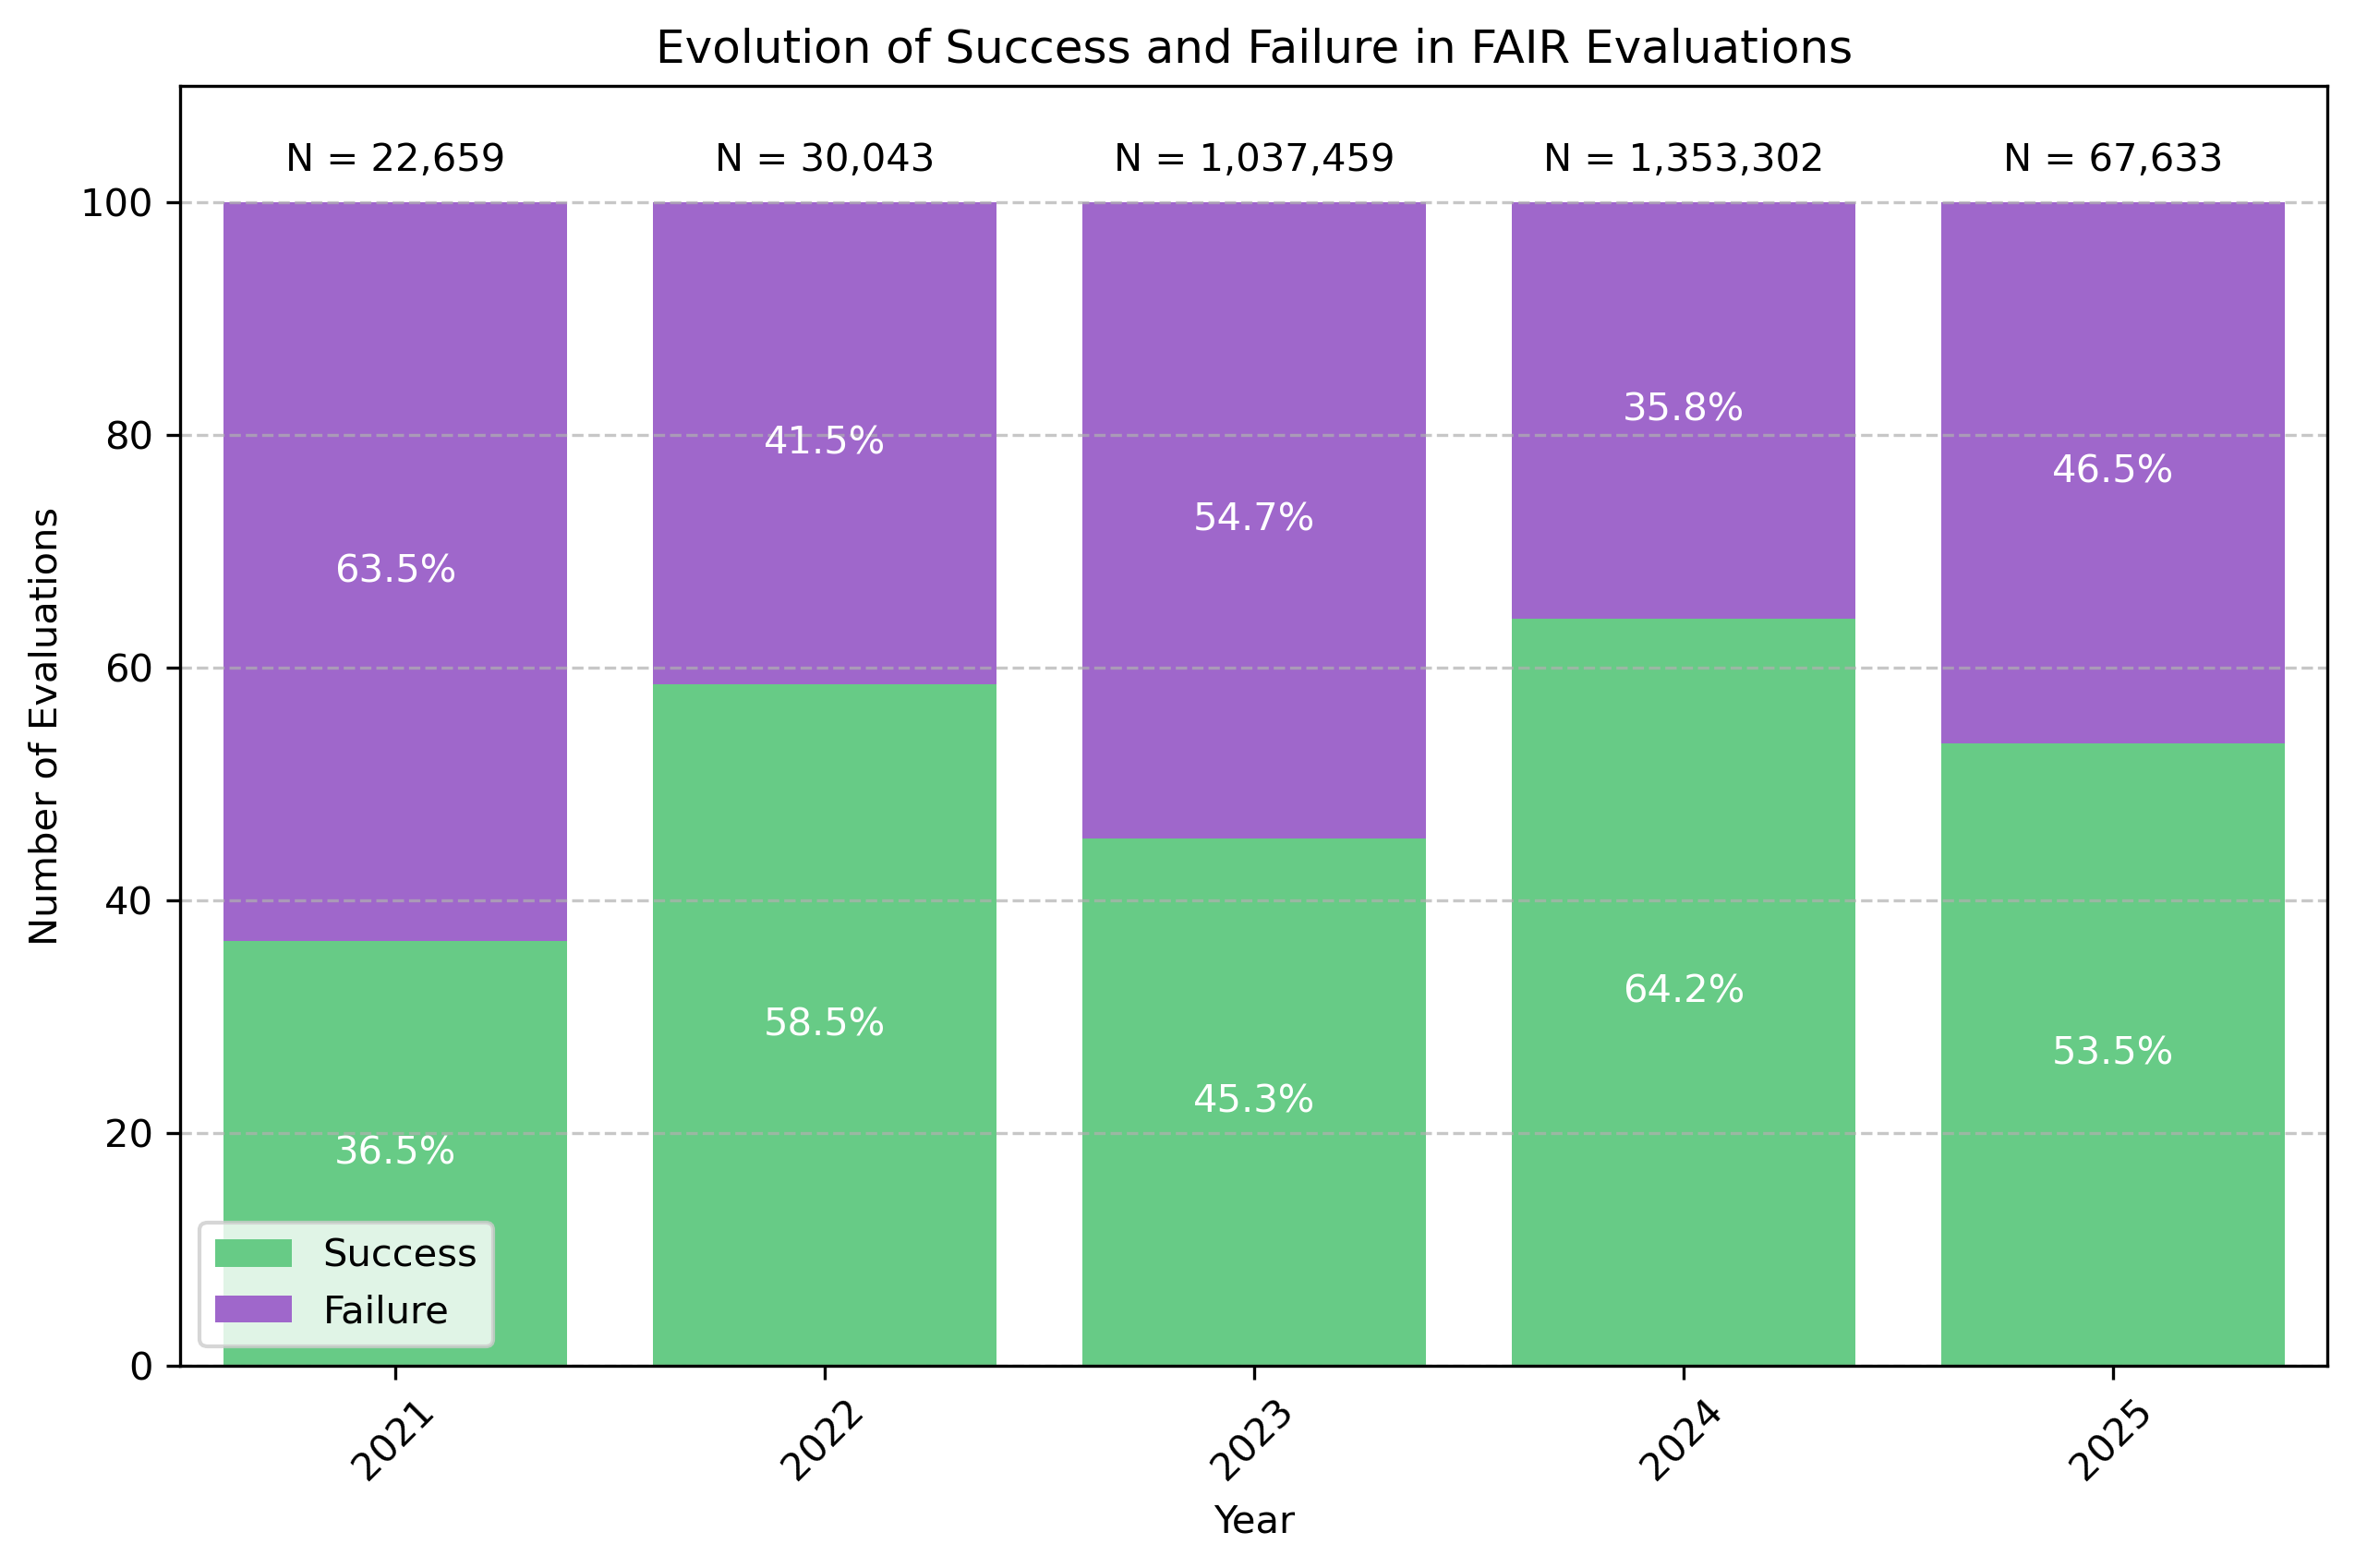

In [2]:
output = pd.read_csv("success_failure_evolution_FAIR.csv")
# plot a stacked bar chart with seaborn of success and failure percentage over the years
plt.figure(figsize=(10, 6), dpi=300)
sns.barplot(
    data=output,
    x="year",
    y="success_percent",
    label="Success",
    color=sns.color_palette("hls", 8)[3],
)
sns.barplot(
    data=output,
    x="year",
    y="failure_percent",
    label="Failure",
    color=sns.color_palette("hls", 8)[6],
    bottom=output["success_percent"],
)
# insert text inside each percent stacked bar in white
for index, row in output.iterrows():
    plt.text(
        x=index,
        y=row['success_percent'] / 2,
        s=f"{row['success_percent']:.1f}%",
        color='white',
        ha='center',
        va='center'
    )
    plt.text(
        x=index,
        y=row['success_percent'] + row['failure_percent'] / 2,
        s=f"{row['failure_percent']:.1f}%",
        color='white',
        ha='center',
        va='center'
    )

# insert the total number of evaluation for each year in black on the top
for index, row in output.iterrows():
    total = row['success'] + row['failure']
    plt.text(
        x=index,
        y=row["success_percent"] + row["failure_percent"] + 2,
        s=f"N = {int(total):,}",
        color="black",
        ha="center",
        va="bottom",
    )

# set the y scale to cover also the 120 value
plt.ylim(0, 110)

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.xlabel("Year")
plt.ylabel("Number of Evaluations")
plt.title("Evolution of Success and Failure in FAIR Evaluations")

plt.savefig("success_failure_evolution.png", dpi=300, format='pdf', bbox_inches='tight')
plt.show

In [7]:
output = pd.read_csv("success_failure_evolution_FAIR.csv")
display(output.head())
# plot a moustache plot with seaborn of success and failure percentage over the years


,year,success,failure,success_percent,failure_percent
0,2021,8266,14393,36.479986,63.520014
1,2022,17590,12453,58.549413,41.450587
2,2023,470108,567351,45.313405,54.686595
3,2024,868315,484987,64.162692,35.837308
4,2025,36184,31449,53.500510,46.499490


#### Progress for F sub-principles

In [164]:
sub_principles = {
    "F": [
        ":F1",
        ":F1A",
        ":F1B",
        ":F2",
        ":F2A",
        ":F2B",
        ":F3",
        ":F4",
    ],
    "A": [":A1.1", ":A1.2"],
    "I": [":I1", ":I2", ":I3"],
    "R": [":R1.1", ":R1.2", ":R1.3"],
}

for k in tqdm(sub_principles.keys()):
    output = pd.DataFrame()
    for YEAR in tqdm(range(2021, 2026)):
        query = f"""
        PREFIX schema: <http://schema.org/>
        PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
        PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
        PREFIX xsd: <http://www.w3.org/2001/XMLSchema#>
        PREFIX dqv: <http://www.w3.org/ns/dqv#>
        PREFIX prov: <http://www.w3.org/ns/prov#>
        PREFIX : <https://fair-checker.france-bioinformatique.fr/data#> 

        SELECT ?value (count(?s) AS ?nb) WHERE {{
            VALUES ?principle {{ {" ".join(sub_principles[k])} }} 
            ?s rdf:type dqv:QualityMeasurement ;
                prov:generatedAtTime ?time ;
                dqv:isMeasurementOf ?principle ;
                dqv:value ?value .
            FILTER (?time >= "{YEAR}-01-01T00:00:00Z"^^xsd:dateTime && ?time <= "{YEAR}-12-31T23:59:59Z"^^xsd:dateTime)
        }} 
        GROUP BY ?value
        ORDER BY desc(?nb)
        """

        results = execute_sparql_query(query)
        #display(results)
        if len(results) > 0:
            # change type of value to int
            results["value"] = results["value"].astype(int)
            results["nb"] = results["nb"].astype(int)

            row = pd.DataFrame(
                {
                    "year": [YEAR],
                    "success": results[results["value"] > 0]["nb"].sum(),
                    "failure": results[results["value"] <= 0]["nb"].sum(),
                }
            )
            output = pd.concat([output, row], ignore_index=True)
        else:
            row = pd.DataFrame(
                {
                    "year": [YEAR],
                    "success": 0,
                    "failure": 0,
                }
            )
            output = pd.concat([output, row], ignore_index=True)

        # save the output to a csv file
        output["success_percent"] = (
            output["success"] / (output["success"] + output["failure"]) * 100
        )
        output["failure_percent"] = (
            output["failure"] / (output["success"] + output["failure"]) * 100
        )
        #display(output)
    output.to_csv(f"success_failure_evolution_{k}.csv", index=False)
    break

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

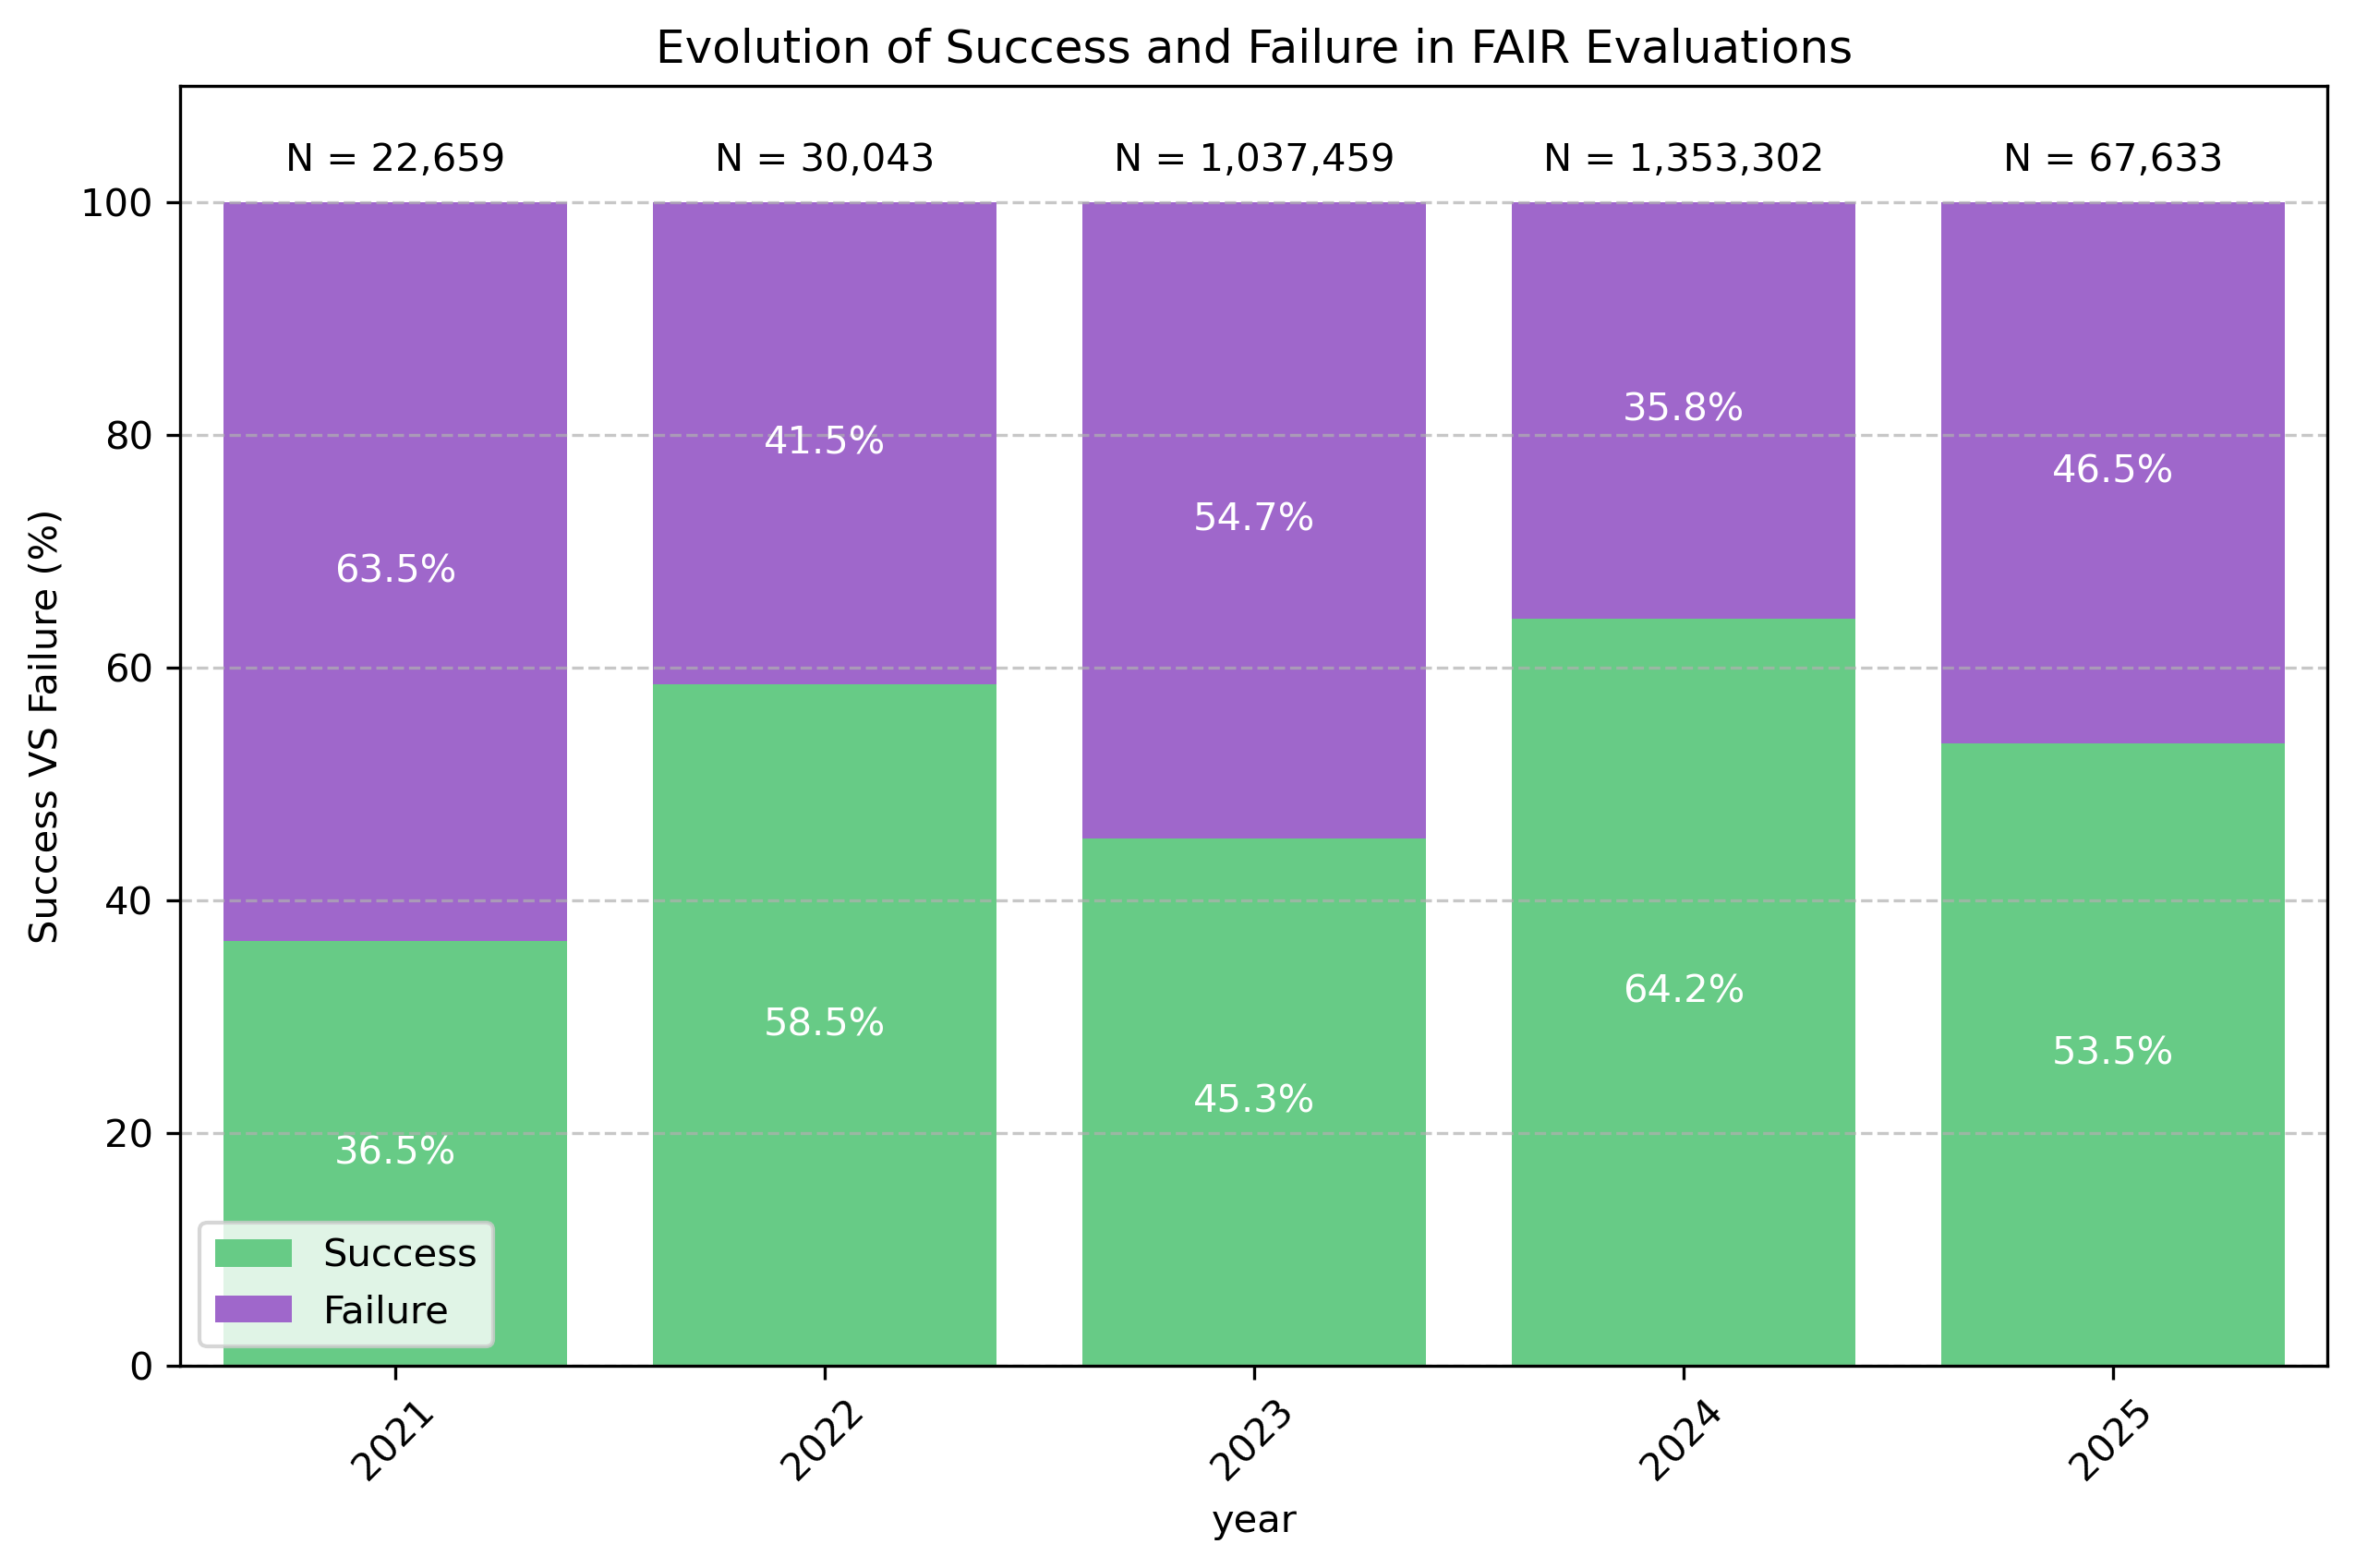

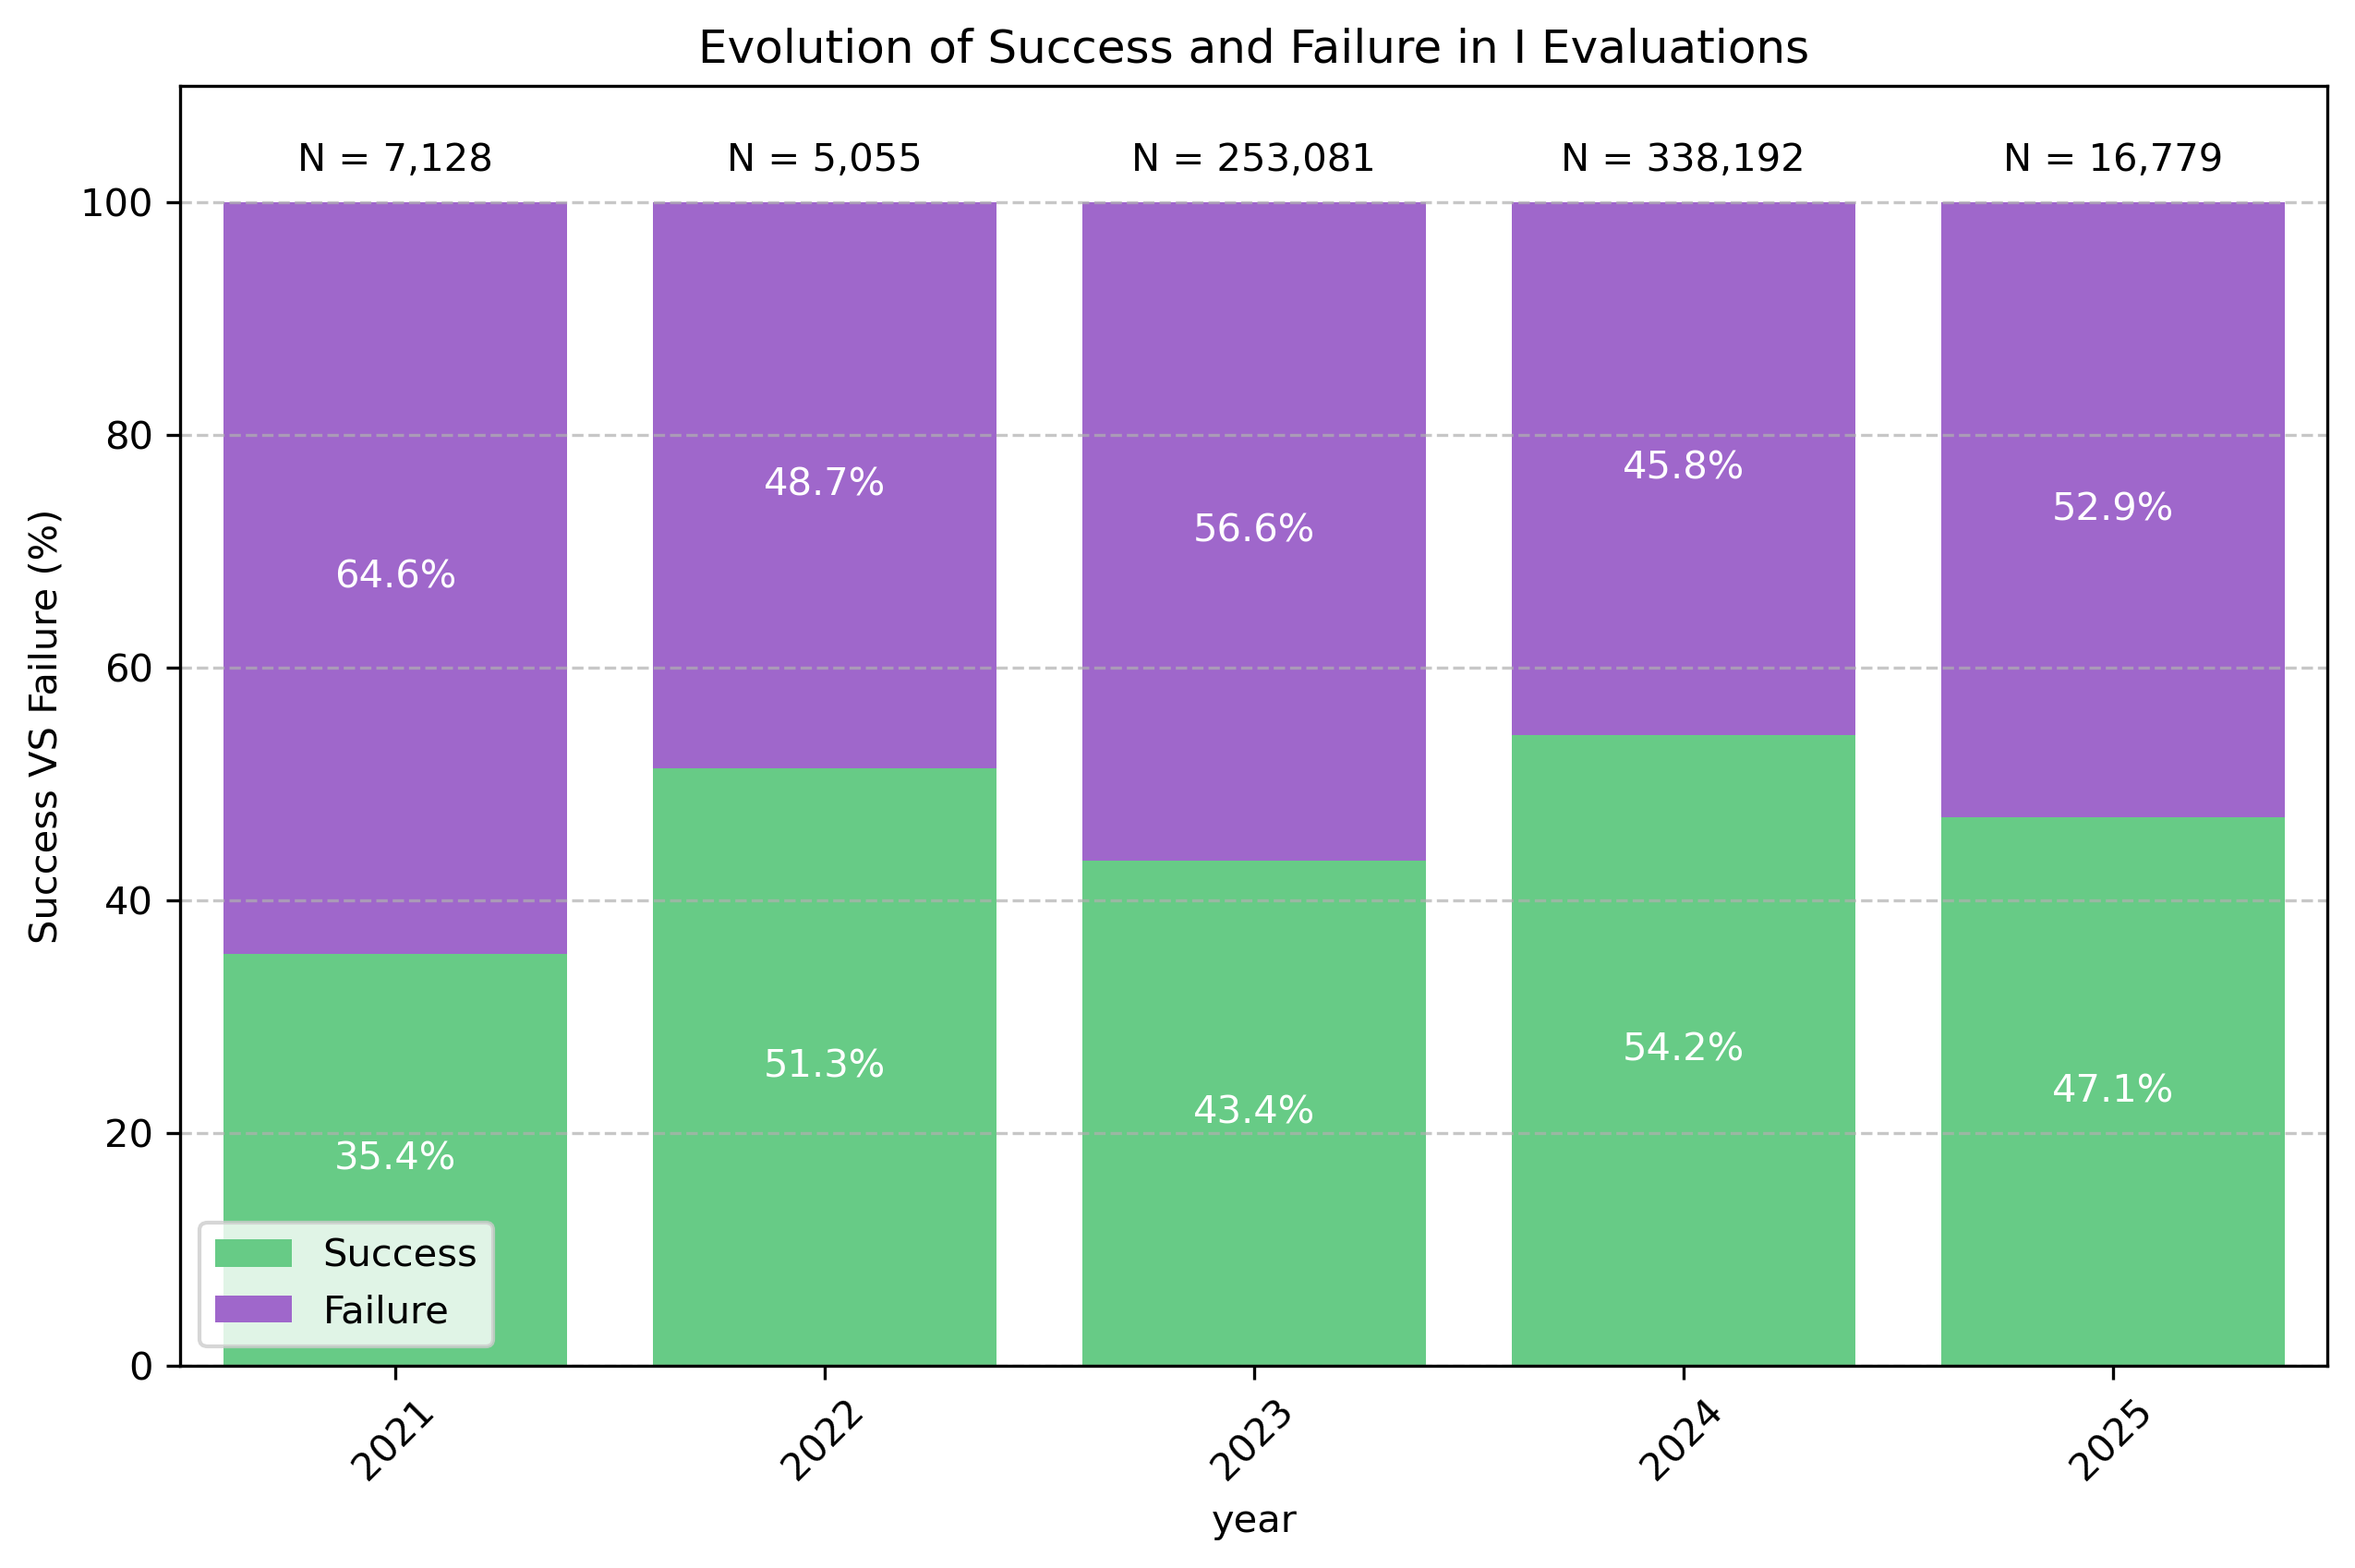

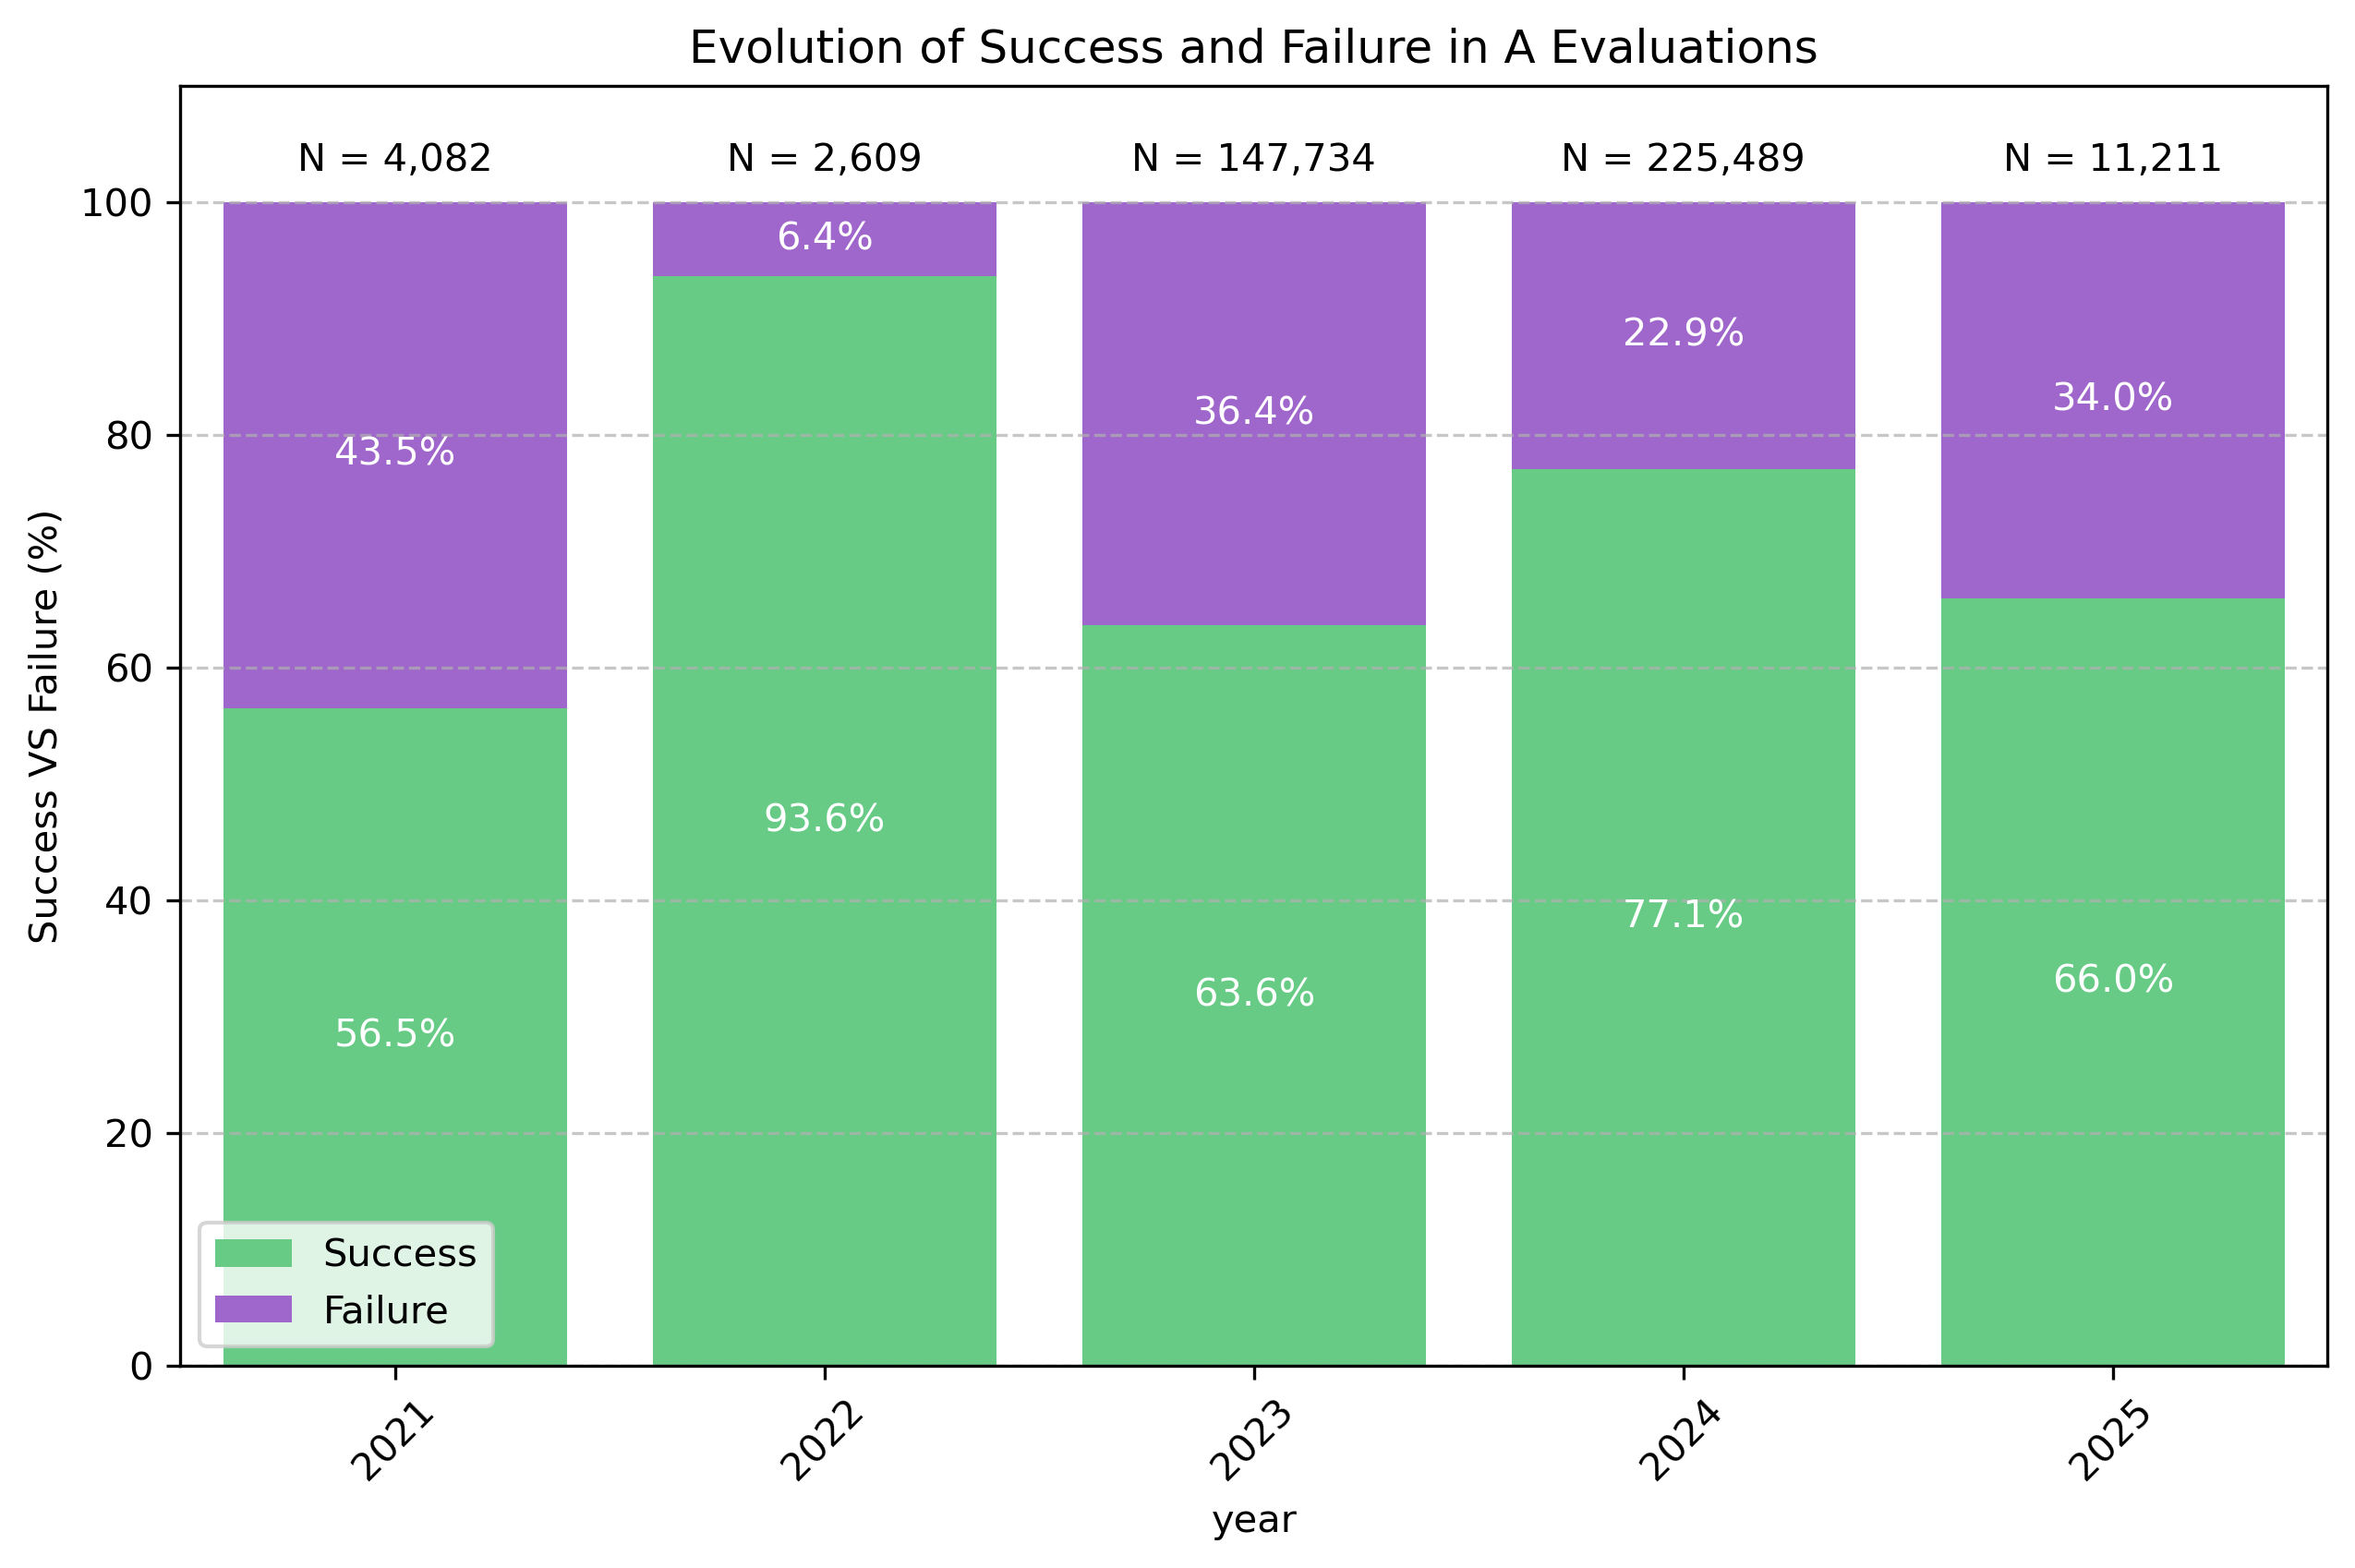

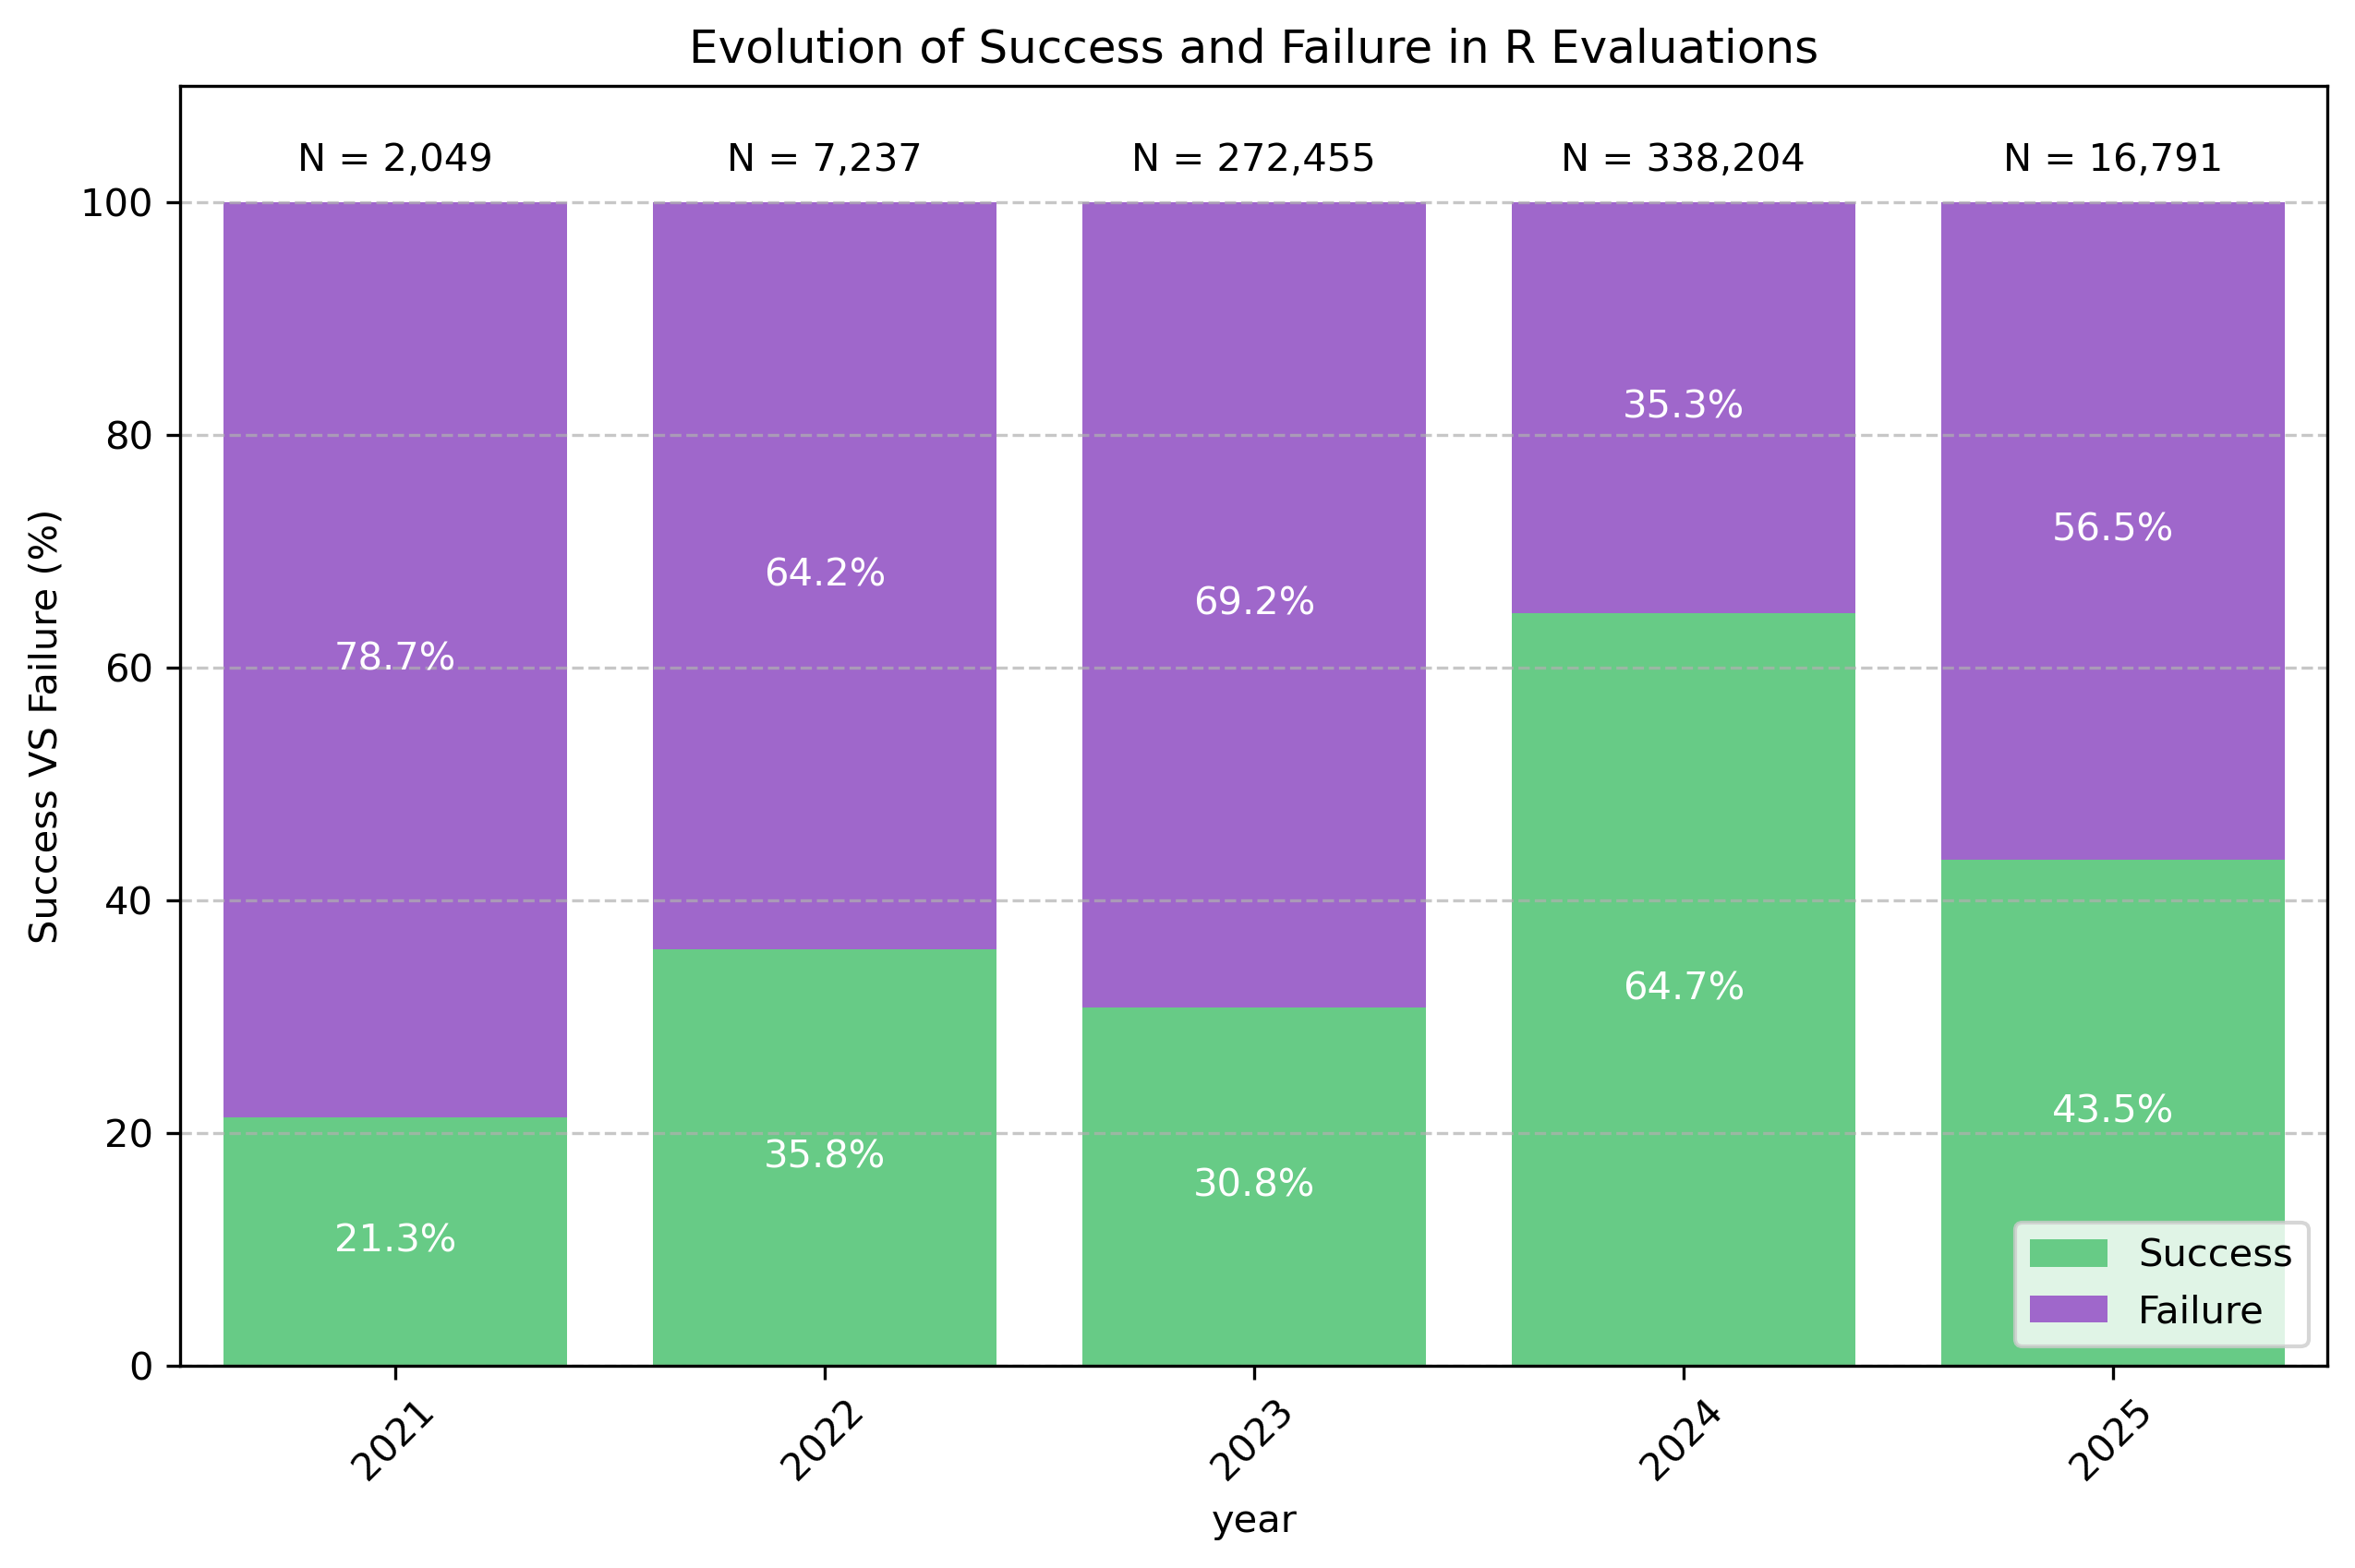

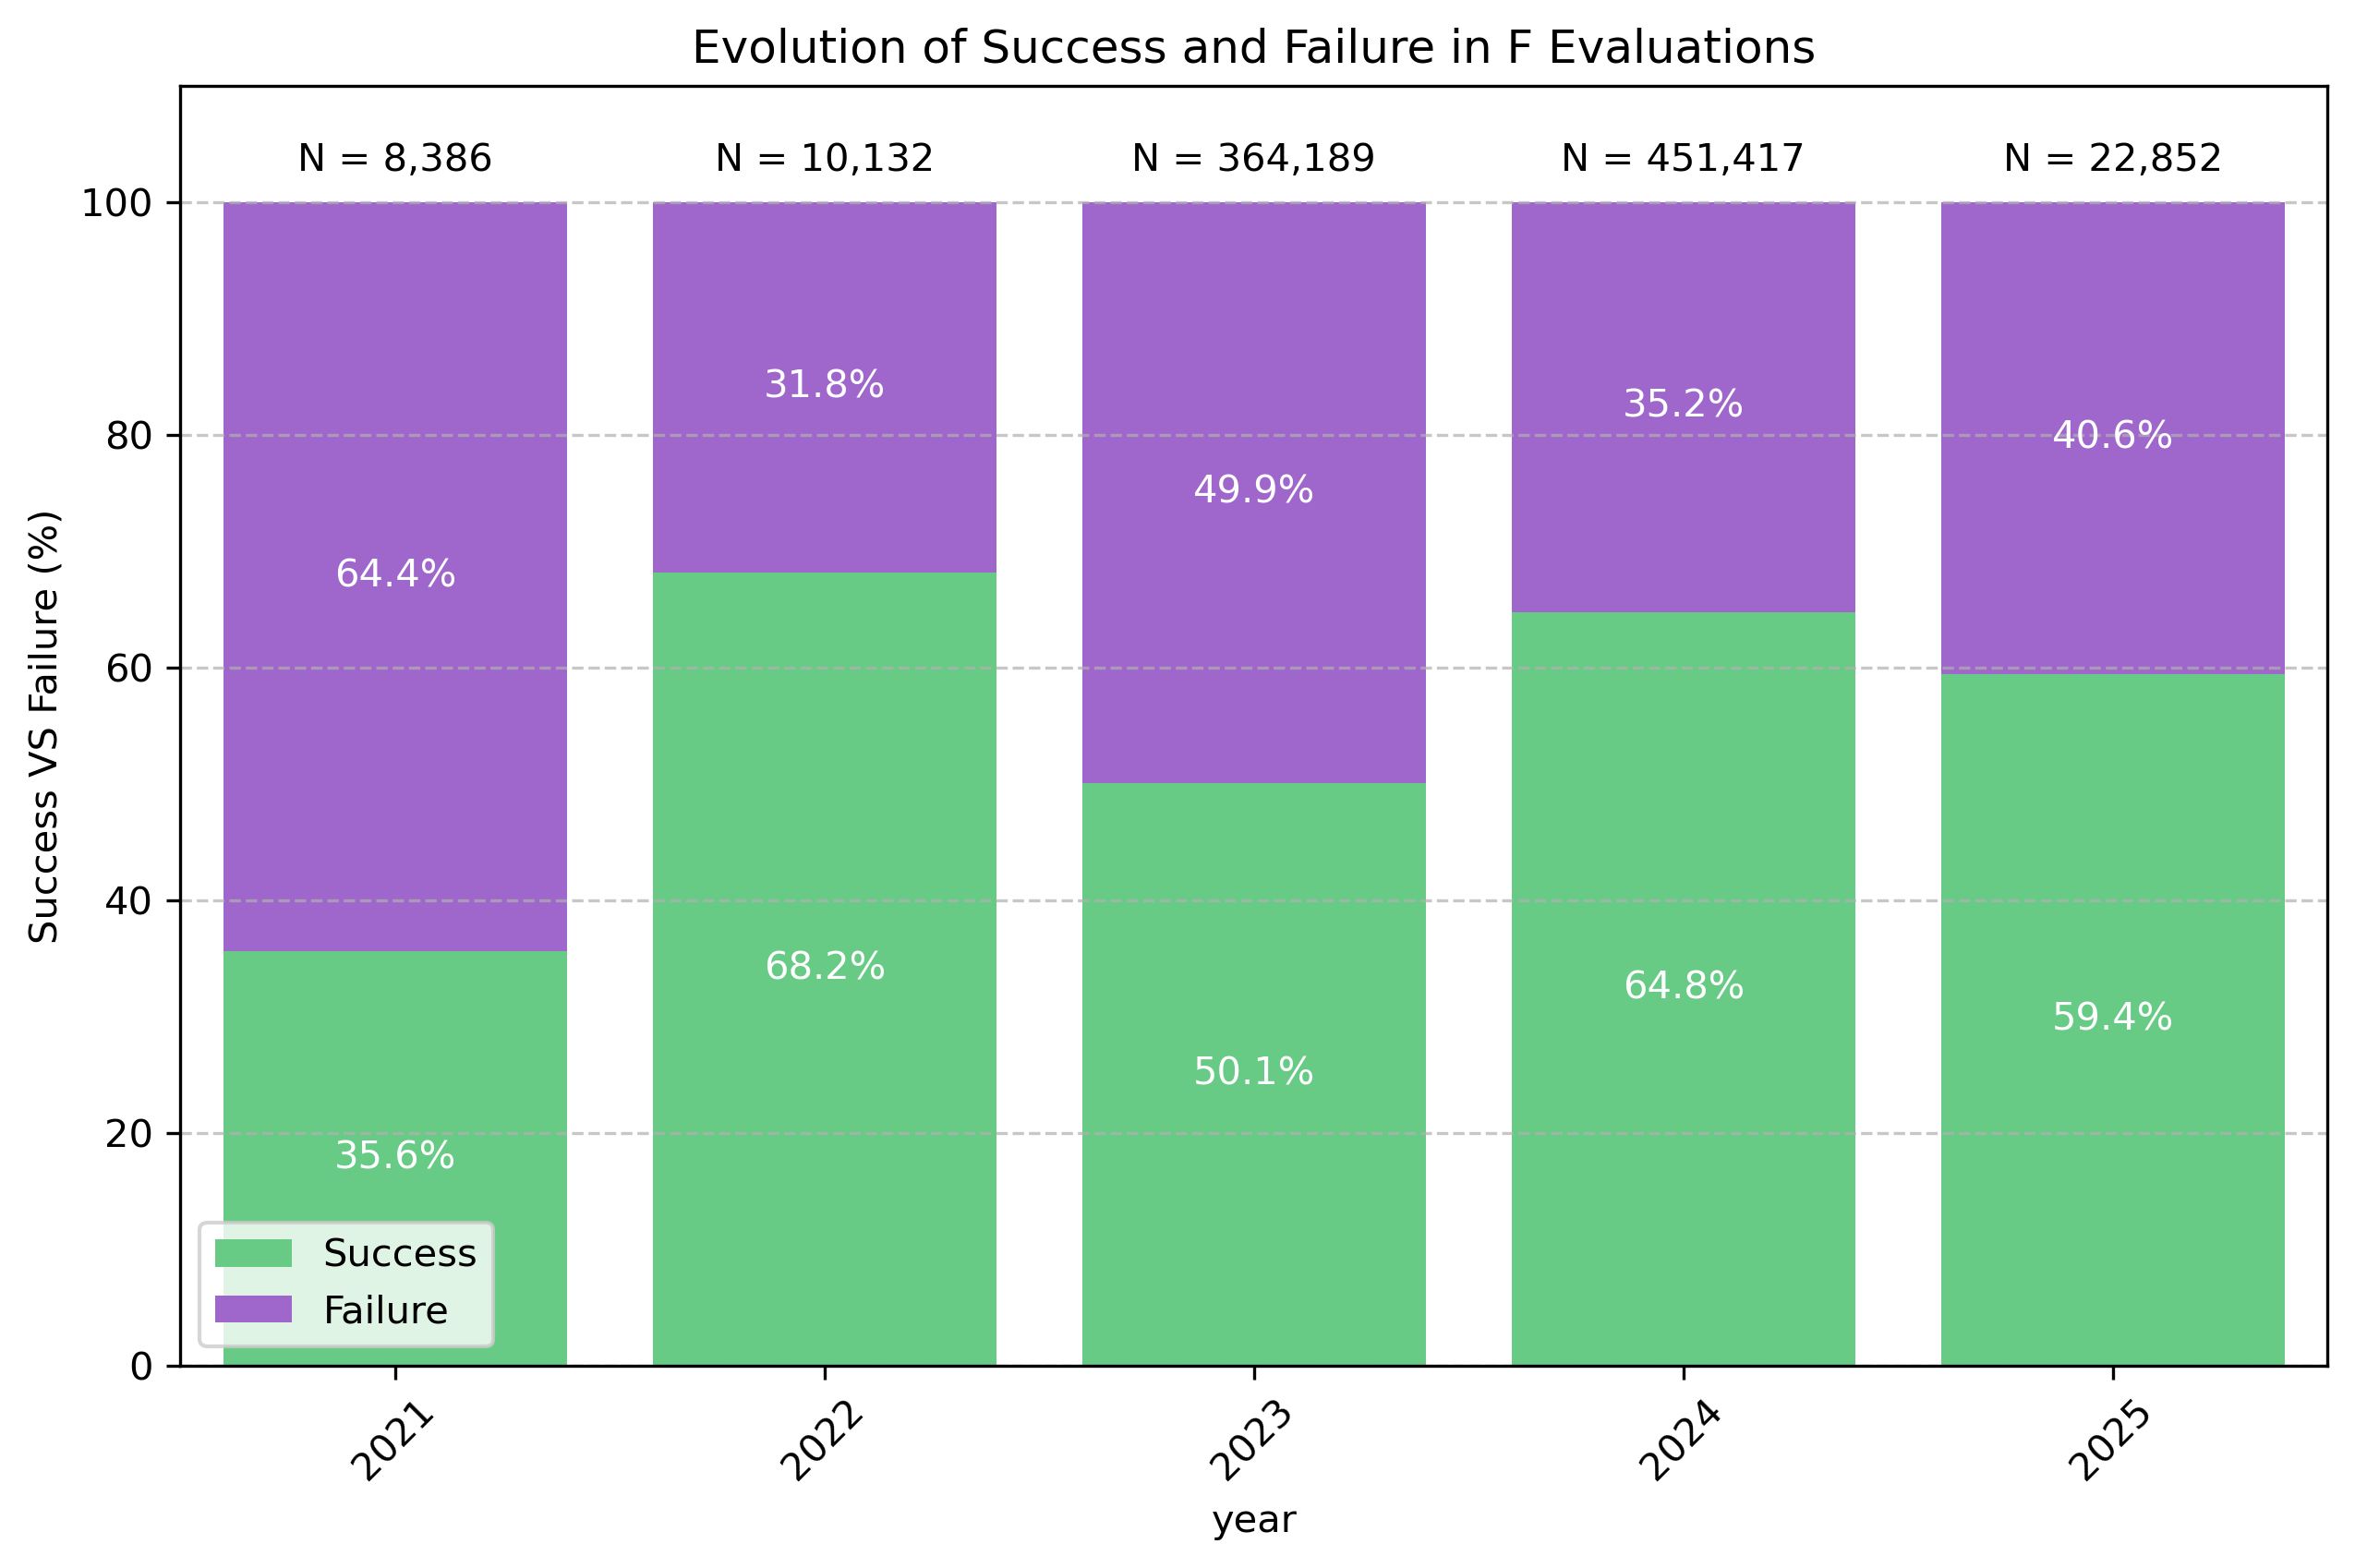

In [169]:
import glob

csvs = glob.glob("success_failure_evolution_*.csv")

for file in csvs:
    principle = file.split("_")[-1]
    principle = principle.split(".csv")[0] 

    output = pd.read_csv(file)

    plt.figure(figsize=(10, 6), dpi=300)
    sns.barplot(
        data=output,
        x="year",
        y="success_percent",
        label="Success",
        color=sns.color_palette("hls", 8)[3],
    )

    sns.barplot(
        data=output,
        x="year",
        y="failure_percent",
        label="Failure",
        color=sns.color_palette("hls", 8)[6],
        bottom=output["success_percent"],
    )
    # insert text inside each percent stacked bar in white
    for index, row in output.iterrows():
        plt.text(
            x=index,
            y=row["success_percent"] / 2,
            s=f"{row['success_percent']:.1f}%",
            color="white",
            ha="center",
            va="center",
        )
        plt.text(
            x=index,
            y=row["success_percent"] + row["failure_percent"] / 2,
            s=f"{row['failure_percent']:.1f}%",
            color="white",
            ha="center",
            va="center",
        )

    # insert the total number of evaluation for each year in black on the top
    for index, row in output.iterrows():
        total = row["success"] + row["failure"]
        plt.text(
            x=index,
            y=row["success_percent"] + row["failure_percent"] + 2,
            s=f"N = {int(total):,}",
            color="black",
            ha="center",
            va="bottom",
        )

    # set the y scale to cover also the 120 value
    plt.ylim(0, 110)

    plt.xticks(rotation=45)
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.legend()
    #plt.xlabel("Year")
    plt.ylabel("Success VS Failure (%)")
    plt.title(f"Evolution of Success and Failure in {principle} Evaluations")

    plt.savefig(
        f"success_failure_evolution_{principle}.pdf",
        dpi=300,
        format="pdf",
        bbox_inches="tight",
    )
    plt.show

## ✅ Multi-evaluated resources over time

In [3]:
query = """
PREFIX schema: <http://schema.org/>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX xsd: <http://www.w3.org/2001/XMLSchema#>
PREFIX dqv: <http://www.w3.org/ns/dqv#>
PREFIX prov: <http://www.w3.org/ns/prov#>
PREFIX : <https://fair-checker.france-bioinformatique.fr/data#> 

SELECT ?year ?month ?computedOn (AVG(xsd:decimal(?value)) AS ?meanValue) WHERE {
    ?s rdf:type dqv:QualityMeasurement ;
        prov:generatedAtTime ?time ;
        dqv:value ?value ;
        dqv:isMeasurementOf ?principle ;
        dqv:computedOn ?computedOn .
    FILTER (?principle NOT IN (:None))
} 
GROUP BY (YEAR(?time) AS ?year) (MONTH(?time) AS ?month) ?computedOn
ORDER BY ?year ?month desc(?meanValue)
"""
results = execute_sparql_query(query)

results["mean_percent"] = results["meanValue"].astype(float) * 100 / 2
results["mean_percent"] = results["mean_percent"].round(2)
results.to_csv("aggregated_fair_assessment_scores.csv", index=False)
results

,year,month,computedOn,meanValue,mean_percent
0,2020,12,https://doi.pangaea.de/10.1594/PANGAEA.914331,0.681818181818181818181818,34.09
1,2020,12,https://zenodo.org/record/154453/,0.681818181818181818181818,34.09
2,2020,12,https://zenodo.org/record/3349821#.Xp7m9SNR2Uk,0.558139534883720930232558,27.91
3,2020,12,https://urgi.versailles.inrae.fr/wheatis-beta,0.454545454545454545454545,22.73
4,2020,12,https://fairsharing.org/FAIRsharing.jptb1m,0.333333333333333333333333,16.67
...,...,...,...,...,...
150385,2025,06,https://open.canada.ca/data/en/api/3/action/da...,0.153846153846153846153846,7.69
150386,2025,06,https://research-portal.st-andrews.ac.uk/en/da...,0.153846153846153846153846,7.69
150387,2025,06,https://freeshib.in/games/dicehttps://freeshib...,0.0,0.00
150388,2025,06,https://freeshib.in/games/dicehttps://freetron...,0.0,0.00


/var/folders/x1/d1nyvpvs0td0htxzsv9x6ggw0000gn/T/ipykernel_93744/3639293050.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/x1/d1nyvpvs0td0htxzsv9x6ggw0000gn/T/ipykernel_93744/3639293050.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Computed On", bbox_to_anchor=(1.05, 1), loc='upper left')


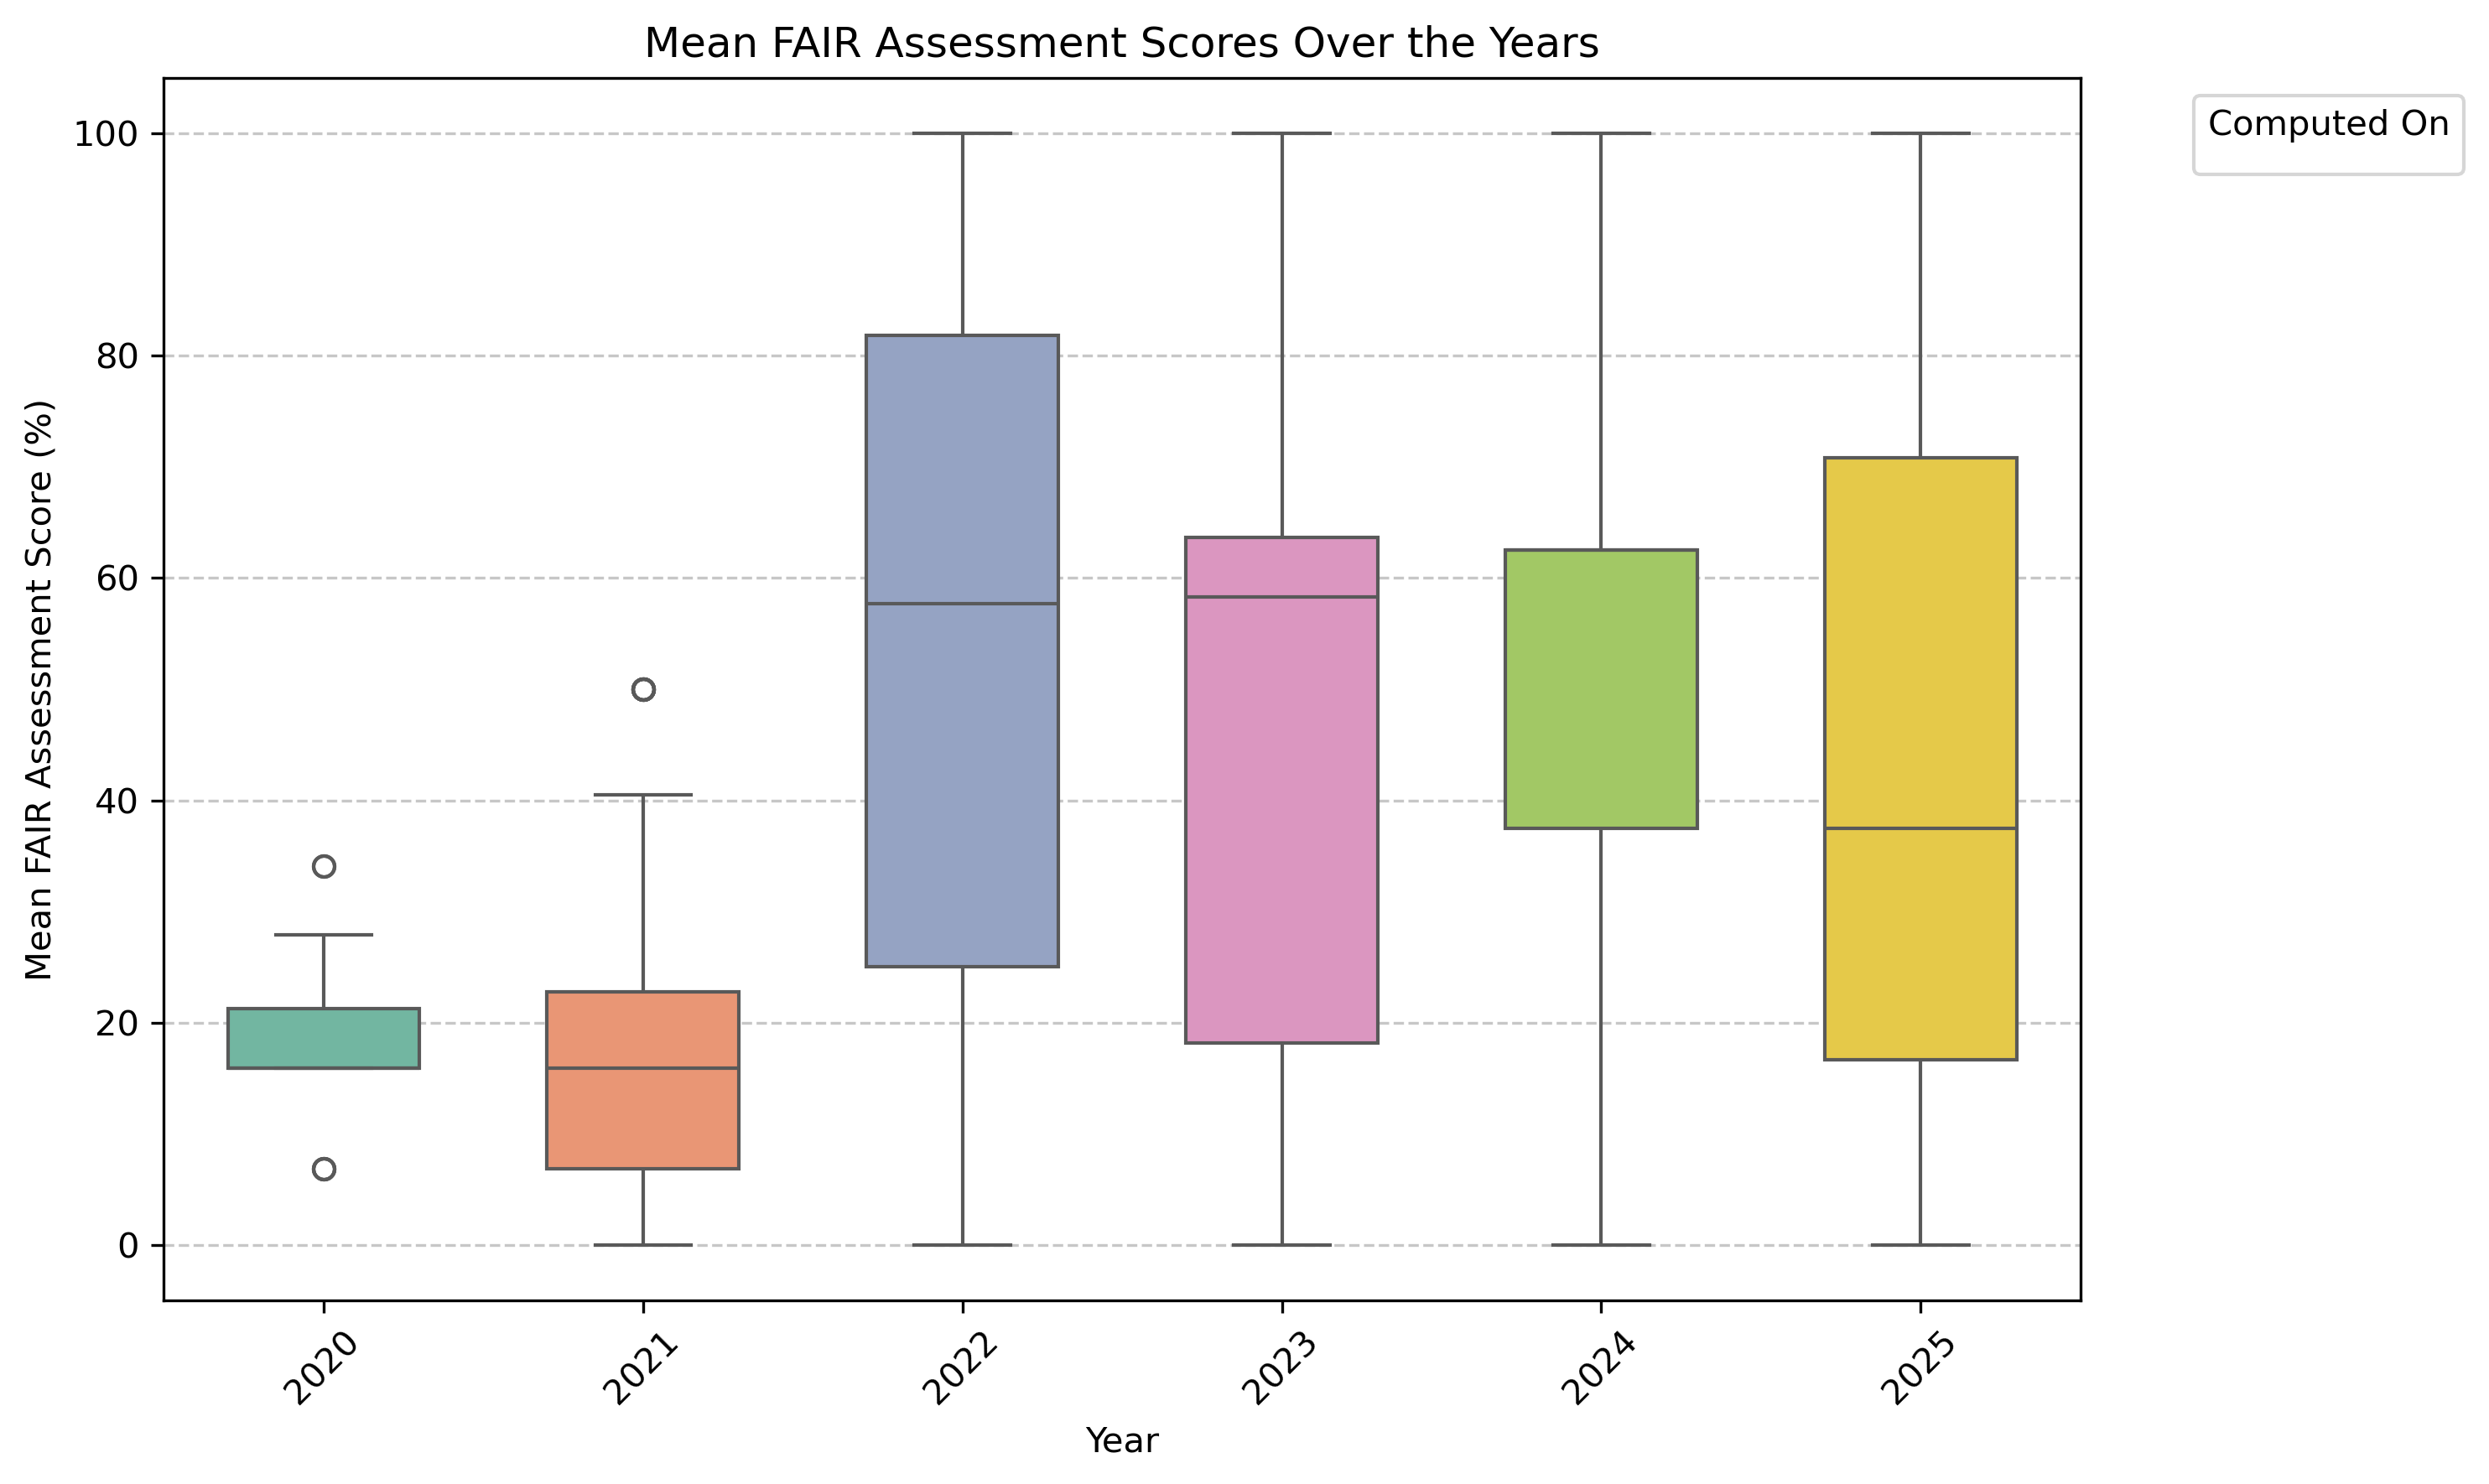

In [2]:
results = pd.read_csv("aggregated_fair_assessment_scores.csv")
# display a moustache plot with seaborn of mean percentage of FAIR assessment scores over the years
plt.figure(figsize=(10, 6), dpi=300)
sns.boxplot(
    data=results,
    x="year",
    y="mean_percent",
    #hue="computedOn",
    palette="Set2",
    showfliers=True,
    width=0.6,
)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title="Computed On", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel("Year")
plt.ylabel("Mean FAIR Assessment Score (%)")
plt.title("Mean FAIR Assessment Scores Over the Years")
plt.tight_layout()
plt.savefig("mean_fair_assessment_scores_over_years.pdf", dpi=300, format='pdf', bbox_inches='tight')
plt.show()

In [ ]:
sub_principles = {
    "F": [
        ":F1",
        ":F1A",
        ":F1B",
        ":F2",
        ":F2A",
        ":F2B",
        ":F3",
        ":F4",
    ],
    "A": [":A1.1", ":A1.2"],
    "I": [":I1", ":I2", ":I3"],
    "R": [":R1.1", ":R1.2", ":R1.3"],
}

merged_stats = pd.DataFrame()

for k in tqdm(sub_principles.keys()):
    query = f"""
    PREFIX schema: <http://schema.org/>
    PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
    PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
    PREFIX xsd: <http://www.w3.org/2001/XMLSchema#>
    PREFIX dqv: <http://www.w3.org/ns/dqv#>
    PREFIX prov: <http://www.w3.org/ns/prov#>
    PREFIX : <https://fair-checker.france-bioinformatique.fr/data#> 
    
    
    SELECT ?year ?month ?computedOn (AVG(xsd:decimal(?value)) AS  ?meanValue) WHERE {{
        VALUES ?principle {{ {" ".join(sub_principles[k])} }} 
        ?s rdf:type dqv:QualityMeasurement ;
            prov:generatedAtTime ?time ;
            dqv:value ?value ;
            dqv:isMeasurementOf ?principle ;
            dqv:computedOn ?computedOn .
        FILTER (?principle NOT IN (:None))
    }} 
    GROUP BY (YEAR(?time) AS ?year) (MONTH(?time) AS ?month) ?computedOn
    ORDER BY ?year ?month desc(?meanValue)
    """
    #print(query)

    results = execute_sparql_query(query)
    
    results["mean_percent"] = results["meanValue"].astype(float) * 100 / 2
    results["mean_percent"] = results["mean_percent"].round(2)
    # rename mean_percent to meanValue
    results = results.rename(columns={"mean_percent": f"mean_{k}_percent"})
    results["year"] = results["year"].astype(int)
    results["month"] = results["month"].astype(int)
    
    
    # merge the results with the merged_stats dataframe
    # by adding a new column for the sub-principle
    results["sub_principle"] = k
    results = results[["year", "month", "computedOn", f"mean_{k}_percent", "sub_principle"]]
    
    # merge the results with the merged_stats dataframe
    # by adding a new column for the sub-principle
    merged_stats = pd.concat([merged_stats, results], ignore_index=True)

# display side by side moustache plots for each mean_{k}_percent

plt.figure(figsize=(10, 6), dpi=300)
sns.boxplot(
    data=merged_stats,
    x="year",
    y="mean_F_percent",
    # hue="computedOn",
    palette="Set2",
    showfliers=True,
    width=0.6,
)
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(title="Computed On", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xlabel("Year")
plt.ylabel("Mean FAIR Assessment Score (%)")
plt.title("Mean FAIR Assessment Scores Over the Years")
plt.tight_layout()
# plt.savefig(
#     f"mean_{k}_assessment_scores_over_years.pdf",
#     dpi=300,
#     format="pdf",
#     bbox_inches="tight",
# )
plt.show()

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [8]:
results = pd.read_csv("aggregated_fair_assessment_scores.csv")
# count the number of occurences of each computedOn and add the results in a new column
results["nbEval"] = results.groupby("computedOn")["meanValue"].transform("count")
display(results.head(50))
# filter out computedOn with less than 2 evaluations
results = results[results["nbEval"] > 1]

res = results.groupby("computedOn")["mean_percent"].min()
results["min_percent"] = results["computedOn"].map(res)

res = results.groupby("computedOn")["mean_percent"].max()
results["max_percent"] = results["computedOn"].map(res)

results["amplitude"] = results["max_percent"] - results["min_percent"]

results = results.sort_values(by=["year", "month", "amplitude"], ascending=False)

# for each computedOn, get the first mean_percent value
results["first_mean_percent"] = results.groupby("computedOn")["mean_percent"].transform("first")

results[results["computedOn"] == "https://orcid.org/0000-0002-6468-9260"]

#results.to_csv("aggregated_multi_fair_assessment_scores.csv", index=False)

,year,month,computedOn,meanValue,mean_percent,nbEval
0,2020,12,https://doi.pangaea.de/10.1594/PANGAEA.914331,0.681818,34.09,53
1,2020,12,https://zenodo.org/record/154453/,0.681818,34.09,1
2,2020,12,https://zenodo.org/record/3349821#.Xp7m9SNR2Uk,0.558140,27.91,2
3,2020,12,https://urgi.versailles.inrae.fr/wheatis-beta,0.454545,22.73,1
4,2020,12,https://fairsharing.org/FAIRsharing.jptb1m,0.333333,16.67,1
5,2020,12,http://bio.tools/bwa,0.318182,15.91,16
6,2020,12,http://bio.tools/jaspar,0.318182,15.91,7
7,2020,12,https://bio.tools/3SRP,0.318182,15.91,1
8,2020,12,https://bio.tools/jaspar,0.318182,15.91,45
9,2020,12,https://bio.tools/rsat_peak-motifs,0.318182,15.91,1


,year,month,computedOn,meanValue,mean_percent,nbEval,min_percent,max_percent,amplitude,first_mean_percent
148683,2025,2,https://orcid.org/0000-0002-6468-9260,0.472222,23.61,3,23.61,38.46,14.85,23.61
147282,2025,1,https://orcid.org/0000-0002-6468-9260,0.750000,37.50,3,23.61,38.46,14.85,23.61
146401,2024,11,https://orcid.org/0000-0002-6468-9260,0.769231,38.46,3,23.61,38.46,14.85,23.61


In [333]:
low = results[(results["amplitude"] > 1) & (results["amplitude"] < 15)]
display(low.head(50))

mid = results[(results["amplitude"] > 33) & (results["amplitude"] < 49)]
display(mid.head(50))

high = results[(results["amplitude"] < 85)]
display(high.head(50))

,year,month,computedOn,meanValue,mean_percent,nbEval,min_percent,max_percent,amplitude
148683,2025,2,https://orcid.org/0000-0002-6468-9260,0.472222,23.61,3,23.61,38.46,14.85
147282,2025,1,https://orcid.org/0000-0002-6468-9260,0.750000,37.50,3,23.61,38.46,14.85
146401,2024,11,https://orcid.org/0000-0002-6468-9260,0.769231,38.46,3,23.61,38.46,14.85
41657,2023,8,https://entrepot.recherche.data.gouv.fr/datase...,1.833333,91.67,4,79.17,93.86,14.69
59909,2023,9,https://entrepot.recherche.data.gouv.fr/datase...,1.833333,91.67,4,79.17,93.86,14.69
36394,2023,7,https://entrepot.recherche.data.gouv.fr/datase...,1.877193,93.86,4,79.17,93.86,14.69
75114,2024,4,https://entrepot.recherche.data.gouv.fr/datase...,1.583333,79.17,4,79.17,93.86,14.69
13654,2023,4,https://raw.githubusercontent.com/arsarkar/met...,1.460177,73.01,3,58.33,73.01,14.68
31009,2023,5,https://raw.githubusercontent.com/arsarkar/met...,1.454545,72.73,3,58.33,73.01,14.68
37101,2023,7,https://raw.githubusercontent.com/arsarkar/met...,1.166667,58.33,3,58.33,73.01,14.68


,year,month,computedOn,meanValue,mean_percent,nbEval,min_percent,max_percent,amplitude
36477,2023,7,https://doi.org/10.3389/fpsyt.2018.00290,1.666667,83.33,5,37.50,86.36,48.86
60540,2023,11,https://doi.org/10.3389/fpsyt.2018.00290,1.416667,70.83,5,37.50,86.36,48.86
72334,2024,2,https://doi.org/10.3389/fpsyt.2018.00290,0.750000,37.50,5,37.50,86.36,48.86
3300,2023,3,https://doi.org/10.3389/fpsyt.2018.00290,1.636364,81.82,5,37.50,86.36,48.86
31280,2023,6,https://doi.org/10.3389/fpsyt.2018.00290,1.727273,86.36,5,37.50,86.36,48.86
1296,2022,4,http://www.atgc-montpellier.fr/phyml,1.384615,69.23,2,20.45,69.23,48.78
361,2021,6,http://www.atgc-montpellier.fr/phyml/,0.409091,20.45,10,20.45,69.23,48.78
417,2021,7,http://www.atgc-montpellier.fr/phyml/,0.454545,22.73,10,20.45,69.23,48.78
149003,2025,3,http://www.atgc-montpellier.fr/phyml/,1.280000,64.00,10,20.45,69.23,48.78
60594,2023,11,http://www.atgc-montpellier.fr/phyml/,1.250000,62.50,10,20.45,69.23,48.78


,year,month,computedOn,meanValue,mean_percent,nbEval,min_percent,max_percent,amplitude
693,2022,2,https://disprot.org,1.545455,77.27,4,6.82,91.67,84.85
60337,2023,10,https://disprot.org,1.833333,91.67,4,6.82,91.67,84.85
772,2022,3,https://disprot.org,1.615385,80.77,4,6.82,91.67,84.85
606,2021,11,https://disprot.org,0.136364,6.82,4,6.82,91.67,84.85
148606,2025,2,https://bio.tools/jaspar,1.238095,61.90,45,15.91,100.00,84.09
2260,2022,11,https://bio.tools/jaspar,1.363636,68.18,45,15.91,100.00,84.09
31025,2023,5,https://bio.tools/jaspar,1.363636,68.18,45,15.91,100.00,84.09
2407,2023,1,https://bio.tools/jaspar,1.363636,68.18,45,15.91,100.00,84.09
31136,2023,5,http://bio.tools/bwa,0.863636,43.18,16,15.91,100.00,84.09
149440,2025,4,http://bio.tools/bwa,1.000000,50.00,16,15.91,100.00,84.09


/var/folders/x1/d1nyvpvs0td0htxzsv9x6ggw0000gn/T/ipykernel_77785/844669106.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["Observation"] = subset["year"].astype(str) + "-" + subset["month"].astype(str)


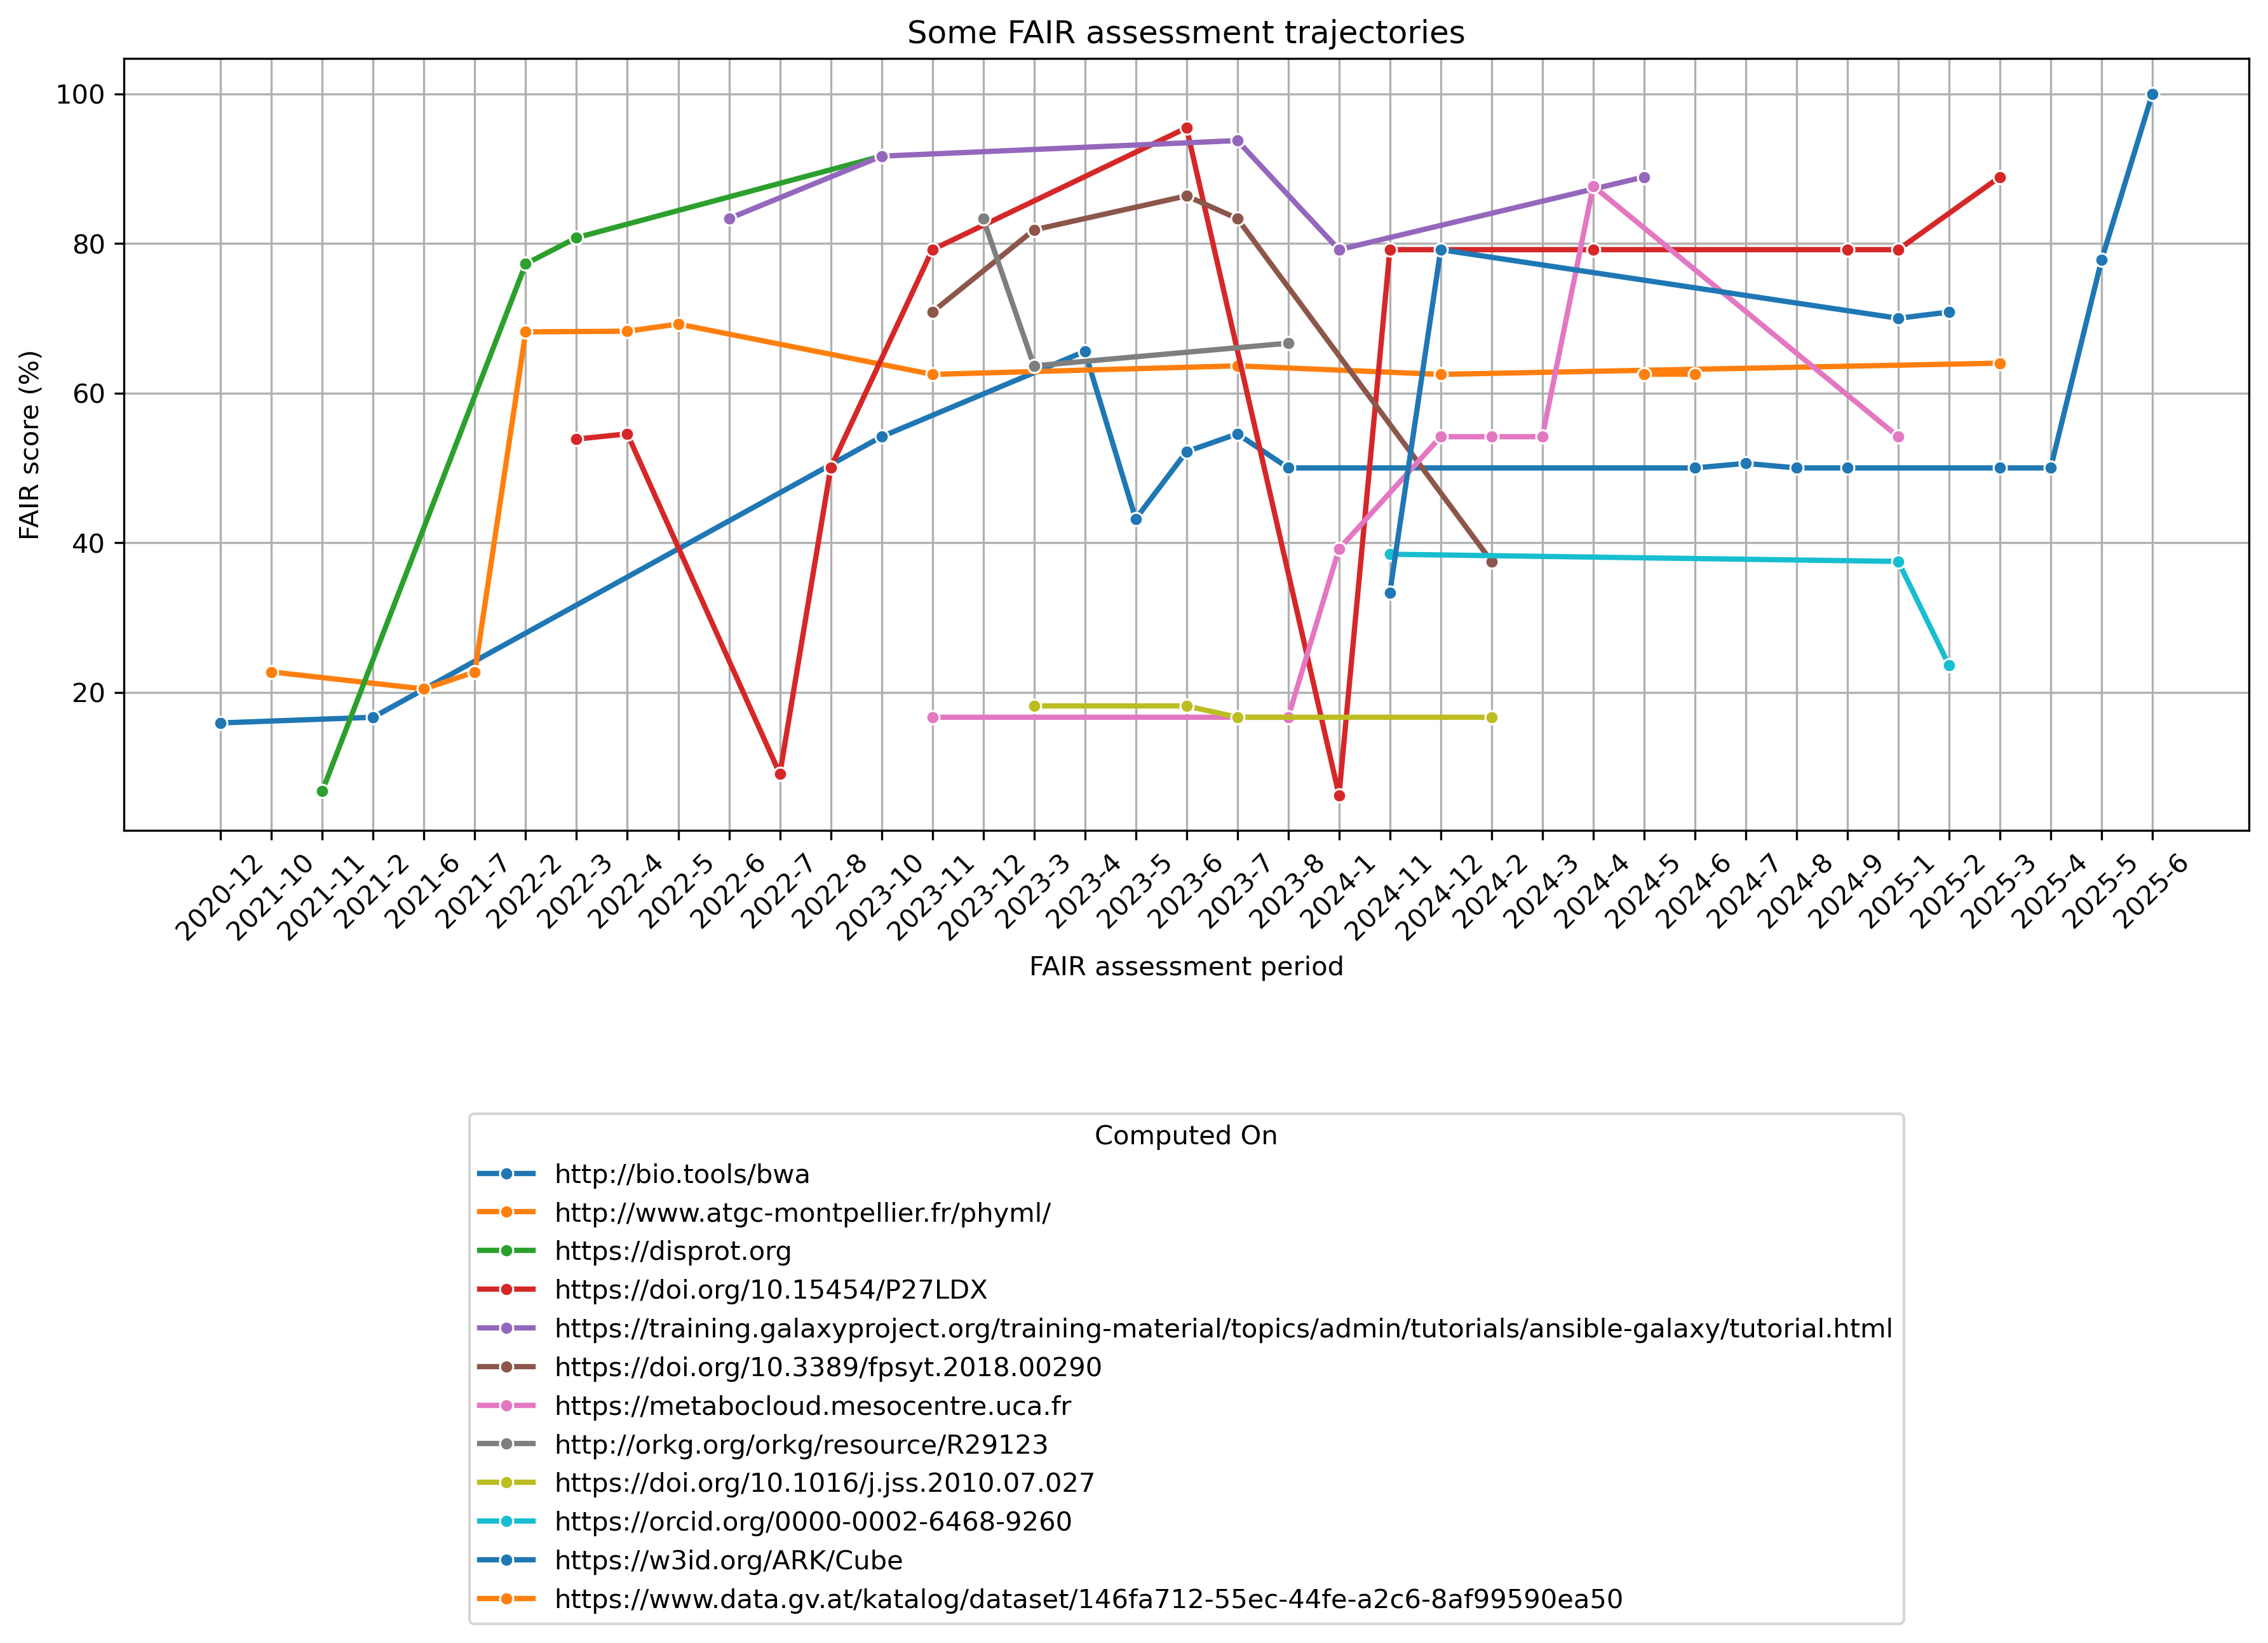

In [ ]:
targets = [
    "https://doi.org/10.15454/P27LDX",
    "http://bio.tools/bwa",
    "https://metabocloud.mesocentre.uca.fr",
    "http://www.purl.org/dabgeo/variant-domain/infrastructurepremise#/",
    "https://www.data.gv.at/katalog/dataset/146fa712-55ec-44fe-a2c6-8af99590ea50",
    "http://orkg.org/orkg/resource/R29123",
    "https://doi.org/10.1016/j.jss.2010.07.027",
    "https://orcid.org/0000-0002-6468-9260",
    "https://training.galaxyproject.org/training-material/topics/admin/tutorials/ansible-galaxy/tutorial.html",
    "https://doi.org/10.3389/fpsyt.2018.00290",
    "http://www.atgc-montpellier.fr/phyml/",
    "https://disprot.org",
    "https://w3id.org/ARK/Cube",
    "https://www.nationalmuseum.ch/sammlung_online/",
]
subset = results[results["computedOn"].isin(targets)]

subset["Observation"] = subset["year"].astype(str) + "-" + subset["month"].astype(str)

subset = subset.sort_values(by=["Observation", "computedOn"])

# do a seaborn lineplot of the mean_percent over time for each computedOn
plt.figure(figsize=(12, 10), dpi=300)
sns.lineplot(
    data=subset, x="Observation", y="mean_percent", hue="computedOn", marker="o", palette="tab10", linewidth=2, markersize=5
)
plt.title("Some FAIR assessment trajectories")
plt.xlabel("FAIR assessment period")
plt.ylabel("FAIR score (%)")
plt.xticks(rotation=45)
# plt.axhline(y=100, color='r', linestyle='--', label='100% Threshold')
# plt.axhline(y=0, color='g', linestyle='--', label='0% Threshold')
# put the legend on the bottom center of the plot
plt.legend(title="Computed On", bbox_to_anchor=(0.5, -0.35), loc="upper center", ncol=1)

plt.grid(True)
plt.tight_layout()
plt.savefig("fair_trajectories.pdf", dpi=300, bbox_inches='tight', format='pdf')
plt.show()